<a href="https://colab.research.google.com/github/HiraNawaz2415/DL-Assignment-1/blob/main/ADL_CompleteAssignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment # 1
## Course Title: Advance Deep learning
## Instructor: Dr Zafar

## Roll no: 25015919-002
##  Class : MSCS SEM 2
## University of Gujrat,Main campus

# Question # 1: Implementation of single perceptrons

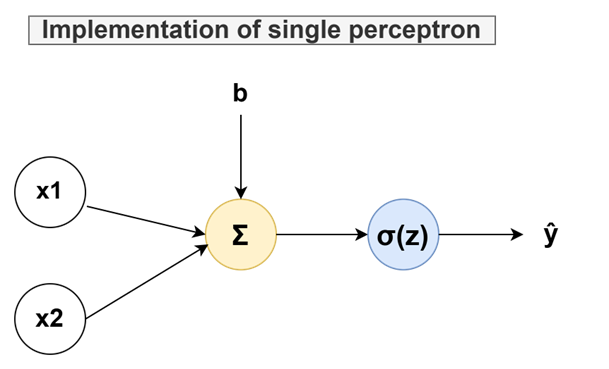
           

## Method 1: Using Manual coding

In [ ]:
import math
import numpy as np

In [ ]:
def activation(z):  # sigmoid activation function
    return 1 / (1 + math.exp(-z))



In [ ]:
def perceptron(X, W, b):

    # Check vector compatibility
    if W.shape[0] != X.shape[0]:
        print("Error: Input and Weight vectors must have same ")
        return None
    else:
        z = 0
        print("Step-by-step calculation:\n")
        for i in range(len(X)):
            product = W[i] * X[i]
            z += product
            print(f"Step {i+1}:")
            print(f"W[{i}] * X[{i}] = {W[i]} * {X[i]} = {product}")
            print(f"Updated z = {z}\n")
        print(f"Adding bias: z = {z} + ({b})")
        z += b
        print(f"Final z after bias = {z}\n")

        # Activation
        y = activation(z)
        print(f"Output after activation = {y}")

        return y


In [ ]:
# Input vector
X = np.array([[1],
              [0]])

In [ ]:
# Weight vector
W = np.array([0.5,-0.6])

In [ ]:
# Bias
b = -0.2

In [ ]:
y = perceptron(X, W, b)

Step-by-step calculation:

Step 1:
W[0] * X[0] = 0.5 * [1] = [0.5]
Updated z = [0.5]

Step 2:
W[1] * X[1] = -0.6 * [0] = [-0.]
Updated z = [0.5]

Adding bias: z = [0.5] + (-0.2)
Final z after bias = [0.3]

Output after activation = 0.574442516811659


/tmp/ipython-input-1730569783.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return 1 / (1 + math.exp(-z))


In [ ]:
def predict(y):
    if y >= 0.5:
        return 1
    else:
        return 0

In [ ]:
print("Final output Manually y =", predict(y))

Final output Manually y = 1


## Method 2: Using built in function

In [ ]:
# import libraries
import numpy as np

In [ ]:
# Input vector
X = np.array([[1],
              [0],[1]])   # x1,x2,x3

In [ ]:
X

array([[1],
       [0],
       [1]])

In [ ]:
# Weight vector
W = np.array([0.5, -0.6, 0.8]) # w1, w2, w3


In [ ]:
W

array([ 0.5, -0.6,  0.8])

In [ ]:
# Bias
b = -0.2

In [ ]:
# Sigmoid activation function
def activation(z):
    return 1 / (1 + math.exp(-z))

In [ ]:
dproduct = np.dot(W,X)

In [ ]:
dproduct

array([1.3])

Calculations of dot product:
(0.5 × 1) + (-0.6 × 0) + (0.8 × 1)


In [ ]:
z = dproduct + b # z = 0.5 + 0 + 0.8 - 0.2

In [ ]:
z

array([1.1])

In [ ]:
# Call the activation function to add non linearity
y = activation(z)

/tmp/ipython-input-564324399.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return 1 / (1 + math.exp(-z))


In [ ]:
def predict(y):
    if y >= 0.5:
        return 1
    else:
        return 0

In [ ]:
# Output
print("Output using built in functions  y =",predict(y))

Output using built in functions  y = 1


# Question # 2: Implementation of multi lyer perceptrons

## 2.1: Two hiden layers each one have only one perceptron

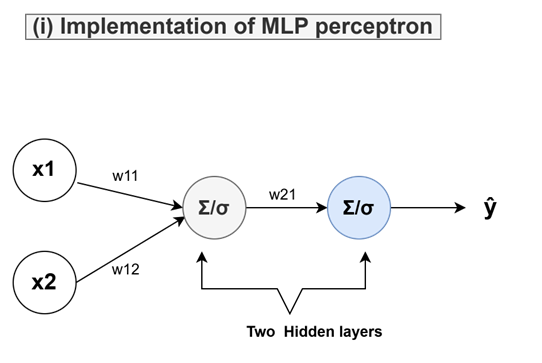

#### Method 1:

In [ ]:
import numpy as np

In [ ]:
# Sigmoid activation (for output)
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [ ]:
# ReLU activation (for hidden layers)
def relu(z):
    return max(0, z)

In [ ]:
# Fully manual MLP
def MLP_manual_stepby_step(X):
    """
    X: Input column vector of shape (2,1)
    """

    n_input = 2  # number of input features

    # General input check
    if not isinstance(X, np.ndarray):
        print("Error: Input must be a numpy array")
        return None
    if X.shape != (n_input,1):
        print(f"Error: Input vector X must have shape ({n_input},1). Current shape: {X.shape}")
        return None
    else:
        # ---- Hidden Layer 1 ----
        # input vector for hidden layer 1 is X
        W1 = np.array([[0.5, -0.4]])  # 1 neuron, 2 inputs
        b1 = 0.2

        Z1 = 0
        for i in range(n_input):
            product = W1[0,i] * X[i,0]
            Z1 += product
            print(f"Hidden Layer 1 - Step {i+1}: Weight * Input = {product}, cumulative Z1 = {Z1}")
        Z1 += b1
        print("Hidden Layer 1 - After adding bias:", Z1)

        H1 = relu(Z1)
        print("Hidden Layer 1 Output after Relu (H1):", H1)

        # ---- Hidden Layer 2 ----
        # inputs for hidden layer 2  is H1 vector
        # weight vector for hidden layer 2
        W2 = np.array([0.7])  # 1 neuron, input from H1
        b2 = -0.3

        Z2 = 0
        # Only one input H1
        product = W2[0] * H1
        Z2 += product
        print(f"Hidden Layer 2: Weight * H1 = {product}, cumulative Z2 = {Z2}")
        Z2 += b2
        print("Hidden Layer 2 - After adding bias:", Z2)

        H2 = relu(Z2)
        print("Hidden Layer 2 Output after Relu (H2):", H2)

        # ---- Output Layer ----
        W3 = np.array([1.2])  # 1 neuron, input from H2
        b3 = 0.1

        Z3 = 0
        product = W3[0] * H2
        Z3 += product
        print(f"Output Layer: Weight * H2 = {product}, cumulative Z3 = {Z3}")
        Z3 += b3
        print("Output Layer - After adding bias:", Z3)

        Y = sigmoid(Z3)
        print("Final Output after Sigmoid (Y):", Y)

        return Y

In [ ]:
X = np.array([[1], [0]])


In [ ]:
y = MLP_manual_stepby_step(X)

Hidden Layer 1 - Step 1: Weight * Input = 0.5, cumulative Z1 = 0.5
Hidden Layer 1 - Step 2: Weight * Input = -0.0, cumulative Z1 = 0.5
Hidden Layer 1 - After adding bias: 0.7
Hidden Layer 1 Output after Relu (H1): 0.7
Hidden Layer 2: Weight * H1 = 0.48999999999999994, cumulative Z2 = 0.48999999999999994
Hidden Layer 2 - After adding bias: 0.18999999999999995
Hidden Layer 2 Output after Relu (H2): 0.18999999999999995
Output Layer: Weight * H2 = 0.22799999999999992, cumulative Z3 = 0.22799999999999992
Output Layer - After adding bias: 0.32799999999999996
Final Output after Sigmoid (Y): 0.5812726666092255


In [ ]:
def predict(y):
    if y >= 0.5:
        return 1
    else:
        return 0

In [ ]:
print("Finally,threshhold check for classification problem y = ",predict(y))

Finally,threshhold check for classification problem y =  1


#### Method 2

In [ ]:
import numpy as np

In [ ]:
# Sigmoid activation
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [ ]:
# ReLU activation (for hidden layers)
def relu(z):
    return max(0, z)

In [ ]:
# Multi-Layer Perceptron manual with robust input check and step-by-step z
def MLP_manual(X):
    """
    X: Input vector, shape must match input layer (n_inputs,1)
    Returns: Output of MLP
    """

    # ---- Layer configuration ----
    # For example, 2-input features → Hidden1(1) → Hidden2(1) → Output(1)
    n_input = 2  # number of input features

    # General input check
    if not isinstance(X, np.ndarray):
        print("Error: Input must be a numpy array")
        return None
    if X.shape != (n_input,1):
        print(f"Error: Input vector X must have shape ({n_input},1). Current shape: {X.shape}")
        return None

    else:
        # ---- Hidden Layer 1 ----
        # input vector for hidden layer 1 is X
        # Weight vector for hidden layer 1
        W1 = np.array([[0.5, -0.4]])  # 1 neuron, 2 inputs
        b1 = np.array([[0.2]])
        Z1 = np.dot(W1, X) + b1
        print("Hidden Layer 1 weighted sum (Z1):", Z1)
        H1 = relu(Z1)
        print("Hidden Layer 1 output after Relu (H1):", H1)

        # ---- Hidden Layer 2 ----
        # input vector for hidden layer 2 is H1
        # Weight vector for hidden layer 1
        W2 = np.array([[0.7]])  # 1 neuron, input from H1
        b2 = np.array([[-0.3]])
        Z2 = np.dot(W2, H1) + b2
        print("Hidden Layer 2 weighted sum (Z2):", Z2)
        H2 = relu(Z2)
        print("Hidden Layer 2 output after Relu (H2):", H2)

        # ---- Output Layer ----
        W3 = np.array([[1.2]])  # 1 neuron, input from H2
        b3 = np.array([[0.1]])
        Z3 = np.dot(W3, H2) + b3
        print("Output Layer weighted sum (Z3):", Z3)
        Y = sigmoid(Z3)
        print("Final Output after Sigmoid (Y):", Y)

        return Y

In [ ]:
# Correct input
X = np.array([[1], [0]])

In [ ]:
X

array([[1],
       [0]])

In [ ]:
y = MLP_manual(X)


Hidden Layer 1 weighted sum (Z1): [[0.7]]
Hidden Layer 1 output after Relu (H1): [[0.7]]
Hidden Layer 2 weighted sum (Z2): [[0.19]]
Hidden Layer 2 output after Relu (H2): [[0.19]]
Output Layer weighted sum (Z3): [[0.328]]
Final Output after Sigmoid (Y): [[0.58127267]]


In [ ]:
def predict(y):
    if y >= 0.5:
        return 1
    else:
        return 0

In [ ]:
print("Finally,threshhold check for classification problem y = ",predict(y))

Finally,threshhold check for classification problem y =  1


In [ ]:
X_wrong = np.array([[1, 0]])  # wrong shape
output_wrong = MLP_manual(X_wrong)

Error: Input vector X must have shape (2,1). Current shape: (1, 2)


## 2.2: Two hiden layers 1st one have two perceptrons and 2nd hidden layer have only one perceptron


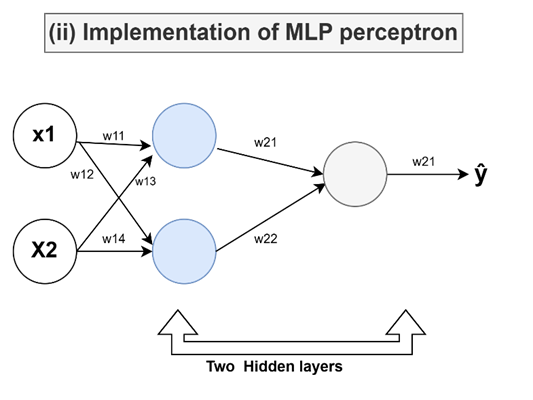

#### Method 1 Manual implementation

In [ ]:
 # ---------- Activation Functions ----------
def relu(z):  # for hidden layers
    return max(0, z)

def sigmoid(z):  # for output layer
    return 1 / (1 + np.exp(-z))

In [ ]:
# ---------- Manual Weighted Sum ----------
def weighted_sum(W, X, b):
    """
    Compute Z = W*X + b manually
    W: weight row vector (1 x n)
    X: input column vector (n x 1)
    b: bias scalar
    """
    Z = 0
    n = X.shape[0]
    for i in range(n):
        Z += W[i] * X[i,0]
        print(f"W[{i}] * X[{i}] = {W[i]*X[i,0]}")
    Z += b
    print(f"Adding bias {b} → Z = {Z}")
    return Z


In [ ]:
# ---------- Multi Layer Perceptron ----------
def MLP_manual_vector(X):

    # -------- General Check --------
    if not isinstance(X, np.ndarray):
        print("Input must be numpy array")
        return None

    if X.shape != (2,1):
        print("Input shape must be (2,1)")
        return None

    print("\nINPUT VECTOR:\n", X)

    # =====================================
    # Hidden Layer 1 (2 Perceptrons)
    # =====================================
    print("\n--- Hidden Layer 1 ---")
    # input vector for hidden layer 1 is X
    W1 = np.array([[0.5, -0.4],   # Neuron 1
                   [0.3, 0.8]])   # Neuron 2
    B1 = np.array([0.2, -0.1])    # Biases

    H1 = np.zeros((2,1))
    for i in range(2):
        z = weighted_sum(W1[i], X, B1[i])
        h = relu(z)
        H1[i,0] = h
        print(f"Neuron {i+1}: z = {z}, h = {h}")

    print("Hidden Layer 1 Output H1:\n", H1)

    # =====================================
    # Hidden Layer 2 (1 Perceptron)
    # =====================================
    print("\n--- Hidden Layer 2 ---")
    # Input vector for hidden layer 2 is H1 from 1st hidden layer
    W2 = np.array([[0.7, 0.6]])   # 1 neuron, weights for H1
    B2 = np.array([-0.3])         # Bias
    Z2 = weighted_sum(W2[0], H1, B2[0])
    H2 = relu(Z2)
    print(f"Hidden Layer 2: z = {Z2}, h = {H2}")

    # =====================================
    # Output Layer
    # =====================================
    print("\n--- Output Layer ---")

    W3 = np.array([1.2])   # 1 neuron, weight for H2
    B3 = 0.1               # Bias
    Z3 = weighted_sum(W3, np.array([[H2]]), B3)
    Y = sigmoid(Z3)
    print(f"Output Layer: z = {Z3}, y = {Y}")

    return Y

In [ ]:
X = np.array([[1], [0]])


In [ ]:
y =MLP_manual_vector(X)


INPUT VECTOR:
 [[1]
 [0]]

--- Hidden Layer 1 ---
W[0] * X[0] = 0.5
W[1] * X[1] = -0.0
Adding bias 0.2 → Z = 0.7
Neuron 1: z = 0.7, h = 0.7
W[0] * X[0] = 0.3
W[1] * X[1] = 0.0
Adding bias -0.1 → Z = 0.19999999999999998
Neuron 2: z = 0.19999999999999998, h = 0.19999999999999998
Hidden Layer 1 Output H1:
 [[0.7]
 [0.2]]

--- Hidden Layer 2 ---
W[0] * X[0] = 0.48999999999999994
W[1] * X[1] = 0.11999999999999998
Adding bias -0.3 → Z = 0.3099999999999999
Hidden Layer 2: z = 0.3099999999999999, h = 0.3099999999999999

--- Output Layer ---
W[0] * X[0] = 0.37199999999999983
Adding bias 0.1 → Z = 0.47199999999999986
Output Layer: z = 0.47199999999999986, y = 0.6158570201970384


In [ ]:
def predict(y):
    if y >= 0.5:
        return 1
    else:
        return 0

In [ ]:
print("Finally, Threshold checking y =",predict(y))

Finally, Threshold checking y = 1


#### Method 2 : using built in function

In [ ]:
# ---------- Activation Functions ----------
def relu(z):
    return np.maximum(0, z)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [ ]:
# ---------- Multi Layer Perceptron using np.dot ----------
def MLP_vectorized(X):

    # -------- General Check --------
    if not isinstance(X, np.ndarray):
        print("Input must be numpy array")
        return None

    if X.shape != (2,1):
        print("Input shape must be (2,1)")
        return None

    print("\nINPUT VECTOR:\n", X)

    # =====================================
    # Hidden Layer 1 (2 Perceptrons)
    # =====================================
    print("\n--- Hidden Layer 1 ---")

    W1 = np.array([[0.5, -0.4],   # Neuron 1
                   [0.3, 0.8]])   # Neuron 2
    B1 = np.array([[0.2], [-0.1]])    # Biases as column vector

    # Weighted sum using dot product
    Z1 = np.dot(W1, X) + B1
    H1 = relu(Z1)  # Apply ReLU element-wise
    print("Z1:\n", Z1)
    print("H1 (after ReLU):\n", H1)

    # =====================================
    # Hidden Layer 2 (1 Perceptron)
    # =====================================
    print("\n--- Hidden Layer 2 ---")

    W2 = np.array([[0.7, 0.6]])   # 1 neuron, weights for H1
    B2 = np.array([[-0.3]])       # Bias as column vector

    Z2 = np.dot(W2, H1) + B2
    H2 = relu(Z2)
    print("Z2:\n", Z2)
    print("H2 (after ReLU):\n", H2)

    # =====================================
    # Output Layer
    # =====================================
    print("\n--- Output Layer ---")

    W3 = np.array([[1.2]])   # 1 neuron, weight for H2
    B3 = np.array([[0.1]])   # Bias as column vector

    Z3 = np.dot(W3, H2) + B3
    Y = sigmoid(Z3)
    print("Z3:\n", Z3)
    print("Final Output Y:\n", Y)

    return Y

In [ ]:
X = np.array([[1], [0]])

In [ ]:
y = MLP_vectorized(X)



INPUT VECTOR:
 [[1]
 [0]]

--- Hidden Layer 1 ---
Z1:
 [[0.7]
 [0.2]]
H1 (after ReLU):
 [[0.7]
 [0.2]]

--- Hidden Layer 2 ---
Z2:
 [[0.31]]
H2 (after ReLU):
 [[0.31]]

--- Output Layer ---
Z3:
 [[0.472]]
Final Output Y:
 [[0.61585702]]


In [ ]:
def predict(y):
    if y >= 0.5:
        return 1
    else:
        return 0

In [ ]:
print("Finally, Threshold checking y =",predict(y))

Finally, Threshold checking y = 1


## 2.3: Three hiden layers 1st two hidden layers have two perceptrons and 3rd hidden layer have only one perceptron

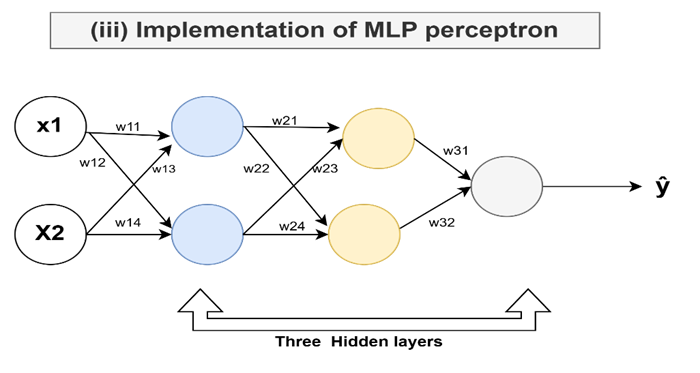

#### Method 1: Manual

In [ ]:
# ---------- Activation Functions ----------
def relu(z):
    return max(0, z)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [ ]:
# ---------- Manual Weighted Sum ----------
def weighted_sum_manual(W, X, b):
    """
    Compute Z = W*X + b manually
    W: weight row vector (1 x n)
    X: input column vector (n x 1)
    b: bias scalar
    """
    Z = 0
    for i in range(len(W)):
        Z += W[i] * X[i,0]
        print(f"W[{i}] * X[{i}] = {W[i]*X[i,0]}")
    Z += b
    print(f"Adding bias {b} → Z = {Z}")
    return Z


In [ ]:
# ---------- Manual 3 Hidden Layer MLP ----------
def MLP_3hidden_manual(X):

    # -------- General Check --------
    if not isinstance(X, np.ndarray):
        print("Input must be numpy array")
        return None
    if X.shape != (2,1):
        print("Input shape must be (2,1)")
        return None

    print("\nINPUT VECTOR:\n", X)

    # =====================================
    # Hidden Layer 1 (2 Neurons)
    # =====================================
    print("\n--- Hidden Layer 1 ---")
    W1 = np.array([[0.5, -0.4],   # Neuron 1
                   [0.3, 0.8]])   # Neuron 2
    B1 = np.array([0.2, -0.1])    # biases

    H1 = np.zeros((2,1))
    for i in range(2):
        z = weighted_sum_manual(W1[i], X, B1[i])
        h = relu(z)
        H1[i,0] = h
        print(f"Neuron {i+1}: z = {z}, h = {h}")
    print("H1 Output:\n", H1)

    # =====================================
    # Hidden Layer 2 (2 Neurons)
    # =====================================
    print("\n--- Hidden Layer 2 ---")
    W2 = np.array([[0.7, 0.6],    # Neuron 1
                   [0.2, 0.9]])   # Neuron 2
    B2 = np.array([-0.3, 0.1])

    H2 = np.zeros((2,1))
    for i in range(2):
        z = weighted_sum_manual(W2[i], H1, B2[i])
        h = relu(z)
        H2[i,0] = h
        print(f"Neuron {i+1}: z = {z}, h = {h}")
    print("H2 Output:\n", H2)

    # =====================================
    # Hidden Layer 3 (1 Neuron)
    # =====================================
    print("\n--- Hidden Layer 3 ---")
    W3 = np.array([0.5, 0.8])  # 1 neuron, weights for H2
    B3 = -0.2

    Z3 = weighted_sum_manual(W3, H2, B3)
    H3 = relu(Z3)
    print(f"Hidden Layer 3: z = {Z3}, h = {H3}")

    # =====================================
    # Output Layer (1 Neuron)
    # =====================================
    print("\n--- Output Layer ---")
    W4 = np.array([1.2])  # 1 neuron, weight for H3
    B4 = 0.1

    Z4 = weighted_sum_manual(W4, np.array([[H3]]), B4)
    Y = sigmoid(Z4)
    print(f"Output Layer: z = {Z4}, y = {Y}")

    return Y


In [ ]:
X = np.array([[1], [0]])



In [ ]:
y =MLP_3hidden_manual(X)


INPUT VECTOR:
 [[1]
 [0]]

--- Hidden Layer 1 ---
W[0] * X[0] = 0.5
W[1] * X[1] = -0.0
Adding bias 0.2 → Z = 0.7
Neuron 1: z = 0.7, h = 0.7
W[0] * X[0] = 0.3
W[1] * X[1] = 0.0
Adding bias -0.1 → Z = 0.19999999999999998
Neuron 2: z = 0.19999999999999998, h = 0.19999999999999998
H1 Output:
 [[0.7]
 [0.2]]

--- Hidden Layer 2 ---
W[0] * X[0] = 0.48999999999999994
W[1] * X[1] = 0.11999999999999998
Adding bias -0.3 → Z = 0.3099999999999999
Neuron 1: z = 0.3099999999999999, h = 0.3099999999999999
W[0] * X[0] = 0.13999999999999999
W[1] * X[1] = 0.18
Adding bias 0.1 → Z = 0.41999999999999993
Neuron 2: z = 0.41999999999999993, h = 0.41999999999999993
H2 Output:
 [[0.31]
 [0.42]]

--- Hidden Layer 3 ---
W[0] * X[0] = 0.15499999999999994
W[1] * X[1] = 0.33599999999999997
Adding bias -0.2 → Z = 0.29099999999999987
Hidden Layer 3: z = 0.29099999999999987, h = 0.29099999999999987

--- Output Layer ---
W[0] * X[0] = 0.34919999999999984
Adding bias 0.1 → Z = 0.4491999999999998
Output Layer: z = 0.449

In [ ]:
def predict(y):
    if y >= 0.5:
        return 1
    else:
        return 0

In [ ]:
print("Finally, Threshold checking y =",predict(y))


Finally, Threshold checking y = 1


#### Method 2: Built in function method

In [ ]:
# ---------- Activation Functions ----------
def relu(Z):
    return np.maximum(0, Z)

def sigmoid(Z):
    return 1 / (1 + np.exp(-Z))

In [ ]:
# ---------- Vectorized 3-Hidden-Layer MLP ----------
def MLP_3hidden_vector(X):

    # -------- General Check --------
    if not isinstance(X, np.ndarray):
        print("Input must be a numpy array")
        return None
    if X.shape != (2,1):
        print("Input shape must be (2,1)")
        return None

    print("\nINPUT VECTOR:\n", X)

    # =====================================
    # Hidden Layer 1 (2 Neurons)
    # =====================================
    print("\n--- Hidden Layer 1 ---")
    # input is X vector
    W1 = np.array([[0.5, -0.4],
                   [0.3, 0.8]])       # shape (2,2)
    B1 = np.array([[0.2],
                   [-0.1]])           # shape (2,1)

    Z1 = np.dot(W1, X) + B1
    H1 = relu(Z1)
    print("Z1:\n", Z1)
    print("H1 (after ReLU):\n", H1)

    # =====================================
    # Hidden Layer 2 (2 Neurons)
    # =====================================
    print("\n--- Hidden Layer 2 ---")
    # input from previous layer H1 vector
    W2 = np.array([[0.7, 0.6],
                   [0.2, 0.9]])       # shape (2,2)
    B2 = np.array([[-0.3],
                   [0.1]])            # shape (2,1)

    Z2 = np.dot(W2, H1) + B2
    H2 = relu(Z2)
    print("Z2:\n", Z2)
    print("H2 (after ReLU):\n", H2)

    # =====================================
    # Hidden Layer 3 (1 Neuron)
    # =====================================
    print("\n--- Hidden Layer 3 ---")
    # input from previous layer H2 vector
    W3 = np.array([[0.5, 0.8]])      # shape (1,2)
    B3 = np.array([[-0.2]])          # shape (1,1)

    Z3 = np.dot(W3, H2) + B3
    H3 = relu(Z3)
    print("Z3:\n", Z3)
    print("H3 (after ReLU):\n", H3)

    # =====================================
    # Output Layer (1 Neuron)
    # =====================================
    print("\n--- Output Layer ---")
    W4 = np.array([[1.2]])           # shape (1,1)
    B4 = np.array([[0.1]])           # shape (1,1)

    Z4 = np.dot(W4, H3) + B4
    Y = sigmoid(Z4)
    print("Z4:\n", Z4)
    print("Final Output Y:\n", Y)

    return Y

In [ ]:
X = np.array([[1], [0]])


In [ ]:
y =MLP_3hidden_manual(X)


INPUT VECTOR:
 [[1]
 [0]]

--- Hidden Layer 1 ---
W[0] * X[0] = 0.5
W[1] * X[1] = -0.0
Adding bias 0.2 → Z = 0.7
Neuron 1: z = 0.7, h = 0.7
W[0] * X[0] = 0.3
W[1] * X[1] = 0.0
Adding bias -0.1 → Z = 0.19999999999999998
Neuron 2: z = 0.19999999999999998, h = 0.19999999999999998
H1 Output:
 [[0.7]
 [0.2]]

--- Hidden Layer 2 ---
W[0] * X[0] = 0.48999999999999994
W[1] * X[1] = 0.11999999999999998
Adding bias -0.3 → Z = 0.3099999999999999
Neuron 1: z = 0.3099999999999999, h = 0.3099999999999999
W[0] * X[0] = 0.13999999999999999
W[1] * X[1] = 0.18
Adding bias 0.1 → Z = 0.41999999999999993
Neuron 2: z = 0.41999999999999993, h = 0.41999999999999993
H2 Output:
 [[0.31]
 [0.42]]

--- Hidden Layer 3 ---
W[0] * X[0] = 0.15499999999999994
W[1] * X[1] = 0.33599999999999997
Adding bias -0.2 → Z = 0.29099999999999987
Hidden Layer 3: z = 0.29099999999999987, h = 0.29099999999999987

--- Output Layer ---
W[0] * X[0] = 0.34919999999999984
Adding bias 0.1 → Z = 0.4491999999999998
Output Layer: z = 0.449

In [ ]:
def predict(y):
    if y >= 0.5:
        return 1
    else:
        return 0

In [ ]:
print("Finally, Threshold checking y =",predict(y))


Finally, Threshold checking y = 1


## 2.4 : Implementation of MLP having 4 hidden layers 1st hidden layer have two perceptrons, 2nd hidden layer have  3 perceptrons , 3rd hidden layer have 2 perceptrons and 4th hidden layer have 1 perceptrons


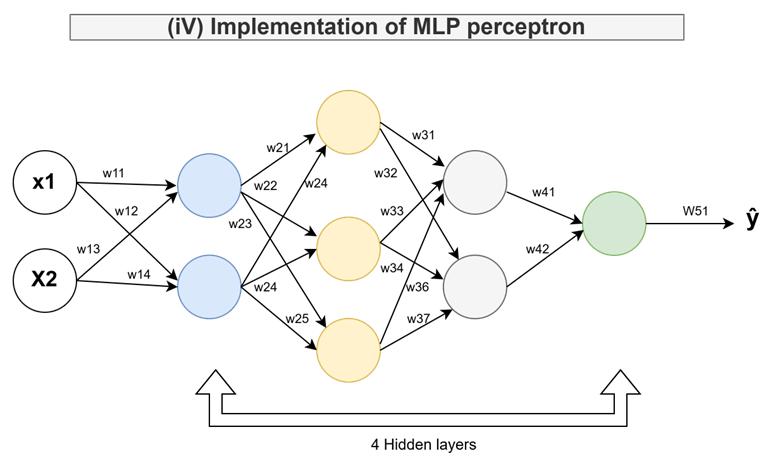

In [ ]:
# ---------- Activation Functions ----------
def relu(Z):
    return np.maximum(0, Z)

def sigmoid(Z):
    return 1 / (1 + np.exp(-Z))


In [ ]:
# ---------- 4 Hidden Layer MLP ----------
def MLP_4Hidden(X):

    # -------- Input Check --------
    if not isinstance(X, np.ndarray):
        print("Input must be numpy array")
        return None

    if X.shape != (2,1):
        print("Input shape must be (2,1)")
        return None

    print("\nINPUT:\n", X)

    # =====================================
    # Hidden Layer 1 (2 neurons)
    # =====================================

    # input vector is X
    W1 = np.array([[0.5, -0.4],
                   [0.3, 0.8]])
    B1 = np.array([[0.2],
                   [-0.1]])

    Z1 = np.dot(W1, X) + B1
    H1 = relu(Z1)
    print("\nH1:\n", H1)

    # =====================================
    # Hidden Layer 2 (3 neurons)
    # =====================================

    # input is H1 vector from previous layer
    W2 = np.array([[0.7, 0.6],
                   [0.2, 0.9],
                   [0.4, -0.5]])
    B2 = np.array([[0.1],
                   [-0.3],
                   [0.2]])

    Z2 = np.dot(W2, H1) + B2
    H2 = relu(Z2)
    print("\nH2:\n", H2)

    # =====================================
    # Hidden Layer 3 (2 neurons)
    # =====================================

    # input from previous layer H2
    W3 = np.array([[0.6, 0.3, 0.5],
                   [0.2, 0.7, -0.4]])
    B3 = np.array([[0.1],
                   [-0.2]])
    Z3 = np.dot(W3, H2) + B3
    H3 = relu(Z3)
    print("\nH3:\n", H3)

    # =====================================
    # Hidden Layer 4 (1 neuron)
    # =====================================

    # input from previous layer H3
    W4 = np.array([[0.8, 0.5]])
    B4 = np.array([[0.2]])
    Z4 = np.dot(W4, H3) + B4
    H4 = relu(Z4)
    print("\nH4:\n", H4)

    # =====================================
    # Output Layer
    # =====================================
    W5 = np.array([[1.2]])
    B5 = np.array([[0.1]])

    Z5 = np.dot(W5, H4) + B5
    Y = sigmoid(Z5)

    print("\nFinal Output:\n", Y)

    return Y

In [ ]:
X = np.array([[1], [0]])

In [ ]:
y= MLP_4Hidden(X)


INPUT:
 [[1]
 [0]]

H1:
 [[0.7]
 [0.2]]

H2:
 [[0.71]
 [0.02]
 [0.38]]

H3:
 [[0.722]
 [0.   ]]

H4:
 [[0.7776]]

Final Output:
 [[0.73752033]]


In [ ]:
def predict(y):
    if y >= 0.5:
        return 1
    else:
        return 0

In [ ]:
print("Finally, Threshold checking y =",predict(y))

Finally, Threshold checking y = 1


# Question # 3: Implememttaion of single perceptron on real dataset and example
## Implementation of Single Perceptron for Mental Stress & Academic Impact Detection Using Student Social Media Dataset

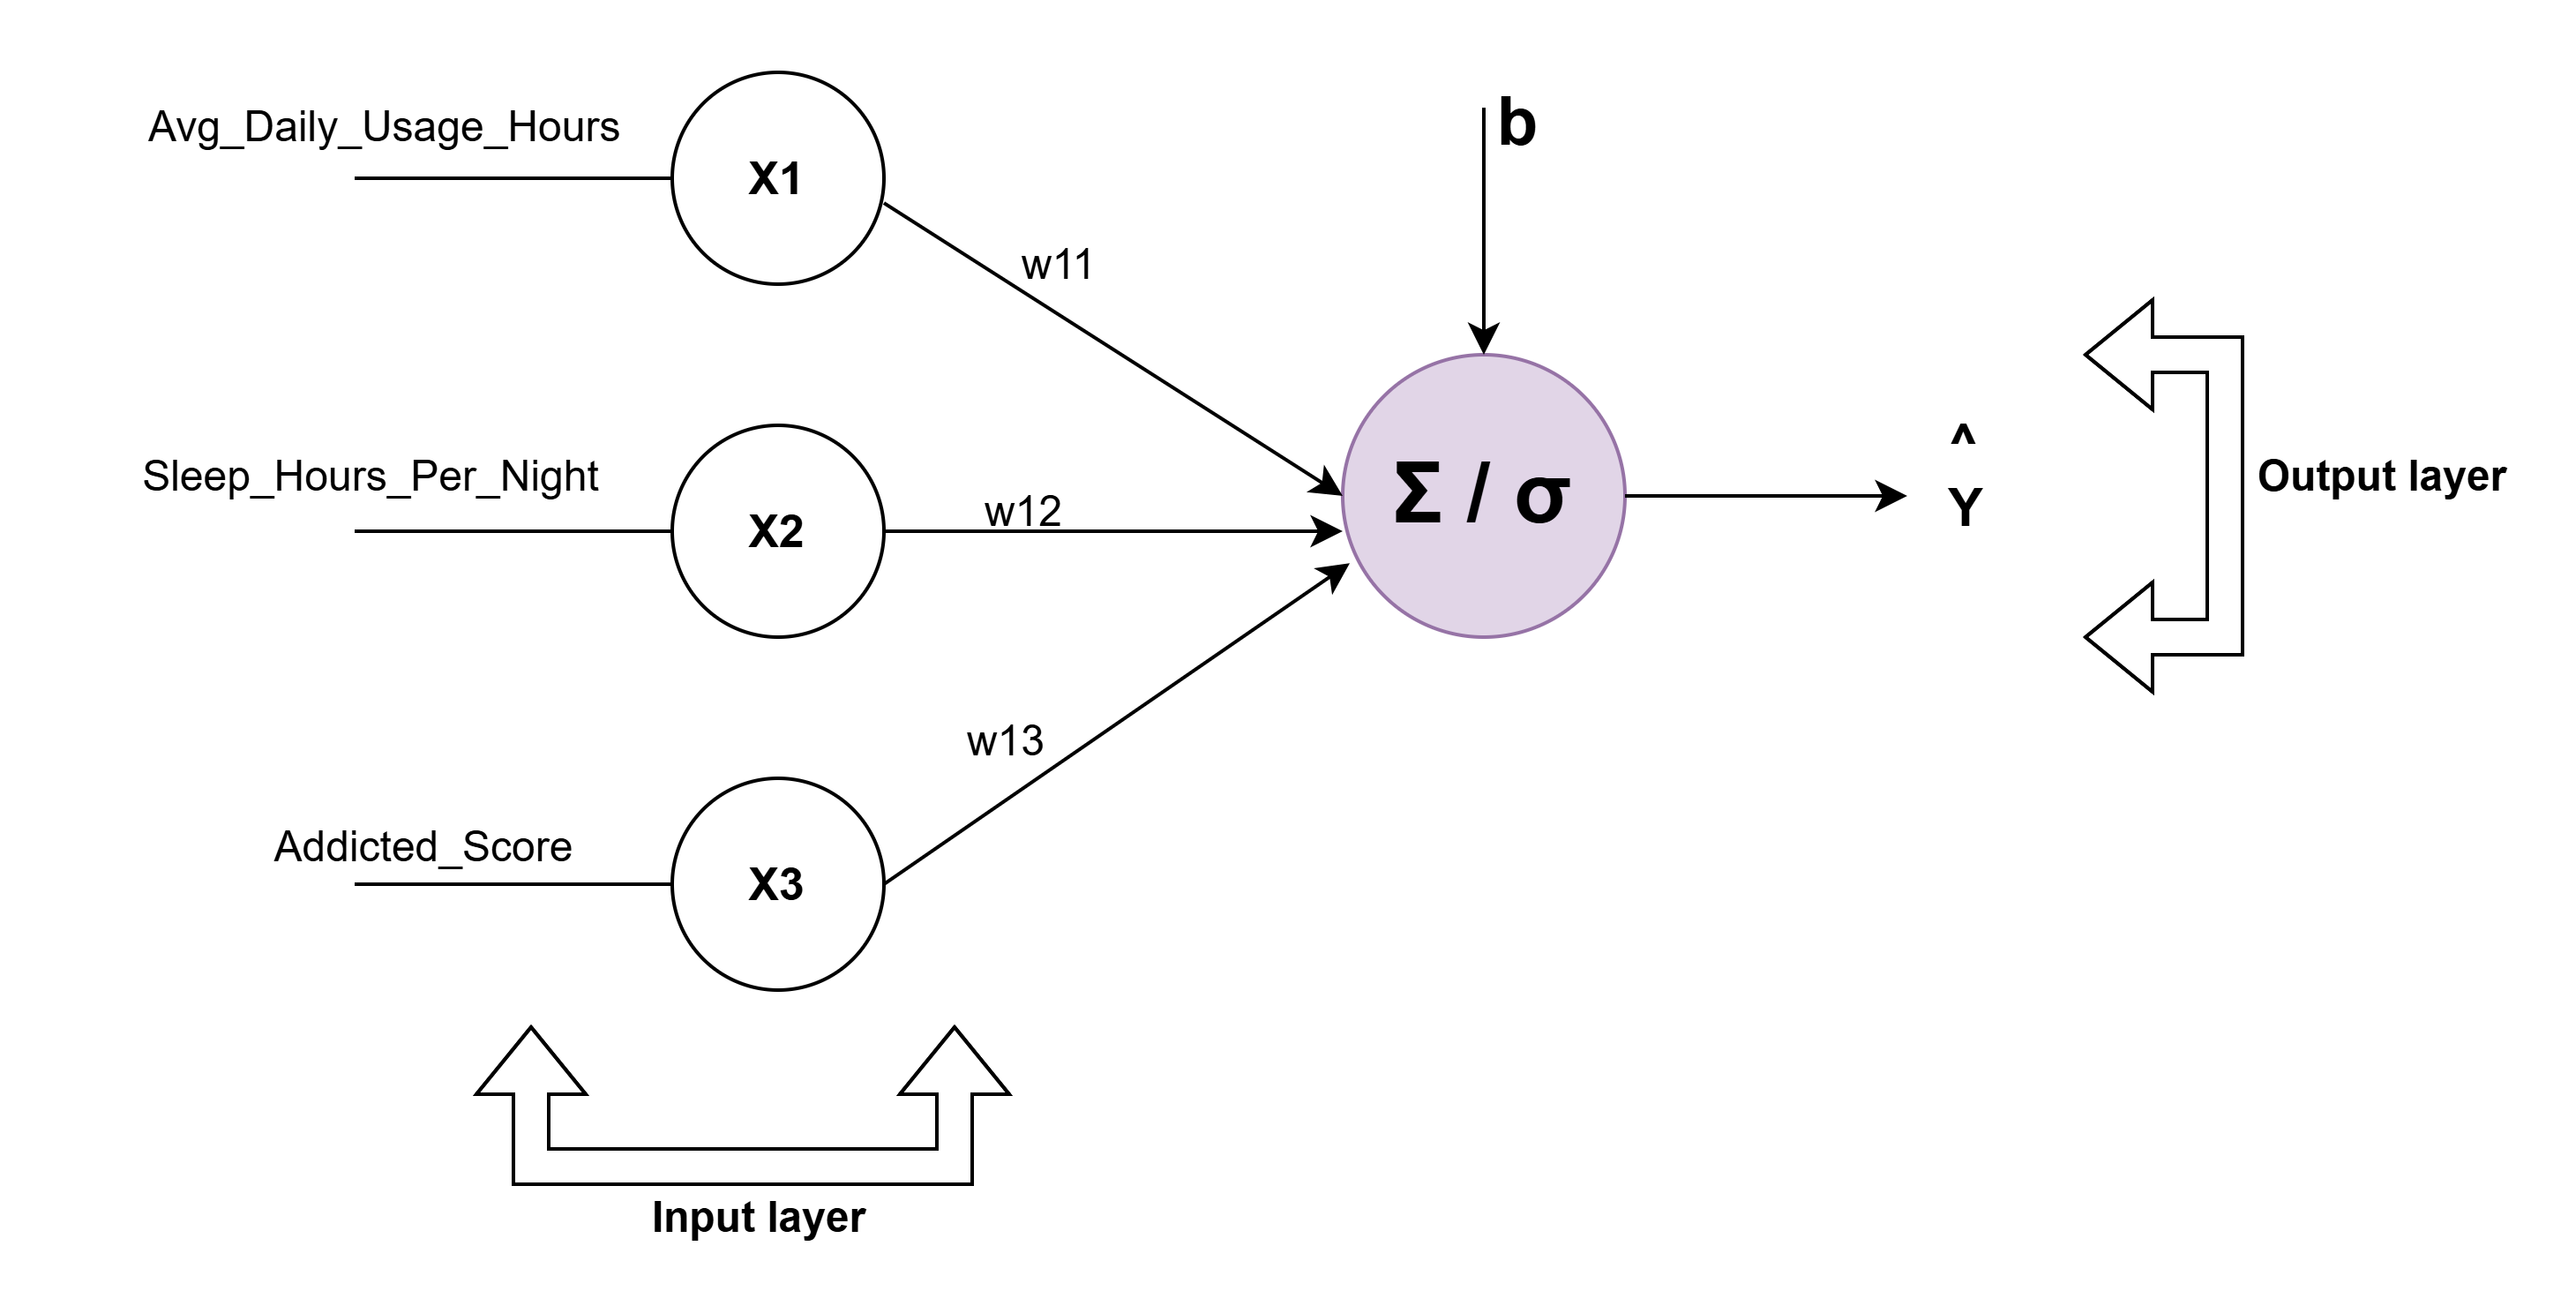

In [ ]:
from google.colab import files
files.upload()  # upload kaggle.json

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"hiranawaz2415","key":"7ade3180923fb5ac9db4b376a34cc842"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets list

ref                                                                  title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-------------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
amar5693/screen-time-sleep-and-stress-analysis-dataset               Screen Time, Sleep & Stress Analysis Dataset            787136  2026-02-13 06:56:18.757000           4464         91  1.0              
amar5693/student-performance-dataset                                 Student Performance Dataset                             177286  2026-02-12 06:04:44.613000           3991         64  1.0              
aliiihussain/amazon-sales-dataset                                    Amazon_Sales_Dataset                                   1297759  2026-02-01 11:37:12.353000           7535      

In [ ]:
!kaggle datasets download -d thedrzee/student-social-media-and-relationships --unzip

Dataset URL: https://www.kaggle.com/datasets/thedrzee/student-social-media-and-relationships
License(s): Attribution 4.0 International (CC BY 4.0)
  0% 0.00/7.67k [00:00<?, ?B/s]
100% 7.67k/7.67k [00:00<00:00, 23.1MB/s]


#### Step 0: Loading of dataset

In [ ]:
import pandas as pd

data = pd.read_csv("Students Social Media Addiction.csv")
print(data.head(5))

   Student_ID  Age  Gender Academic_Level     Country  Avg_Daily_Usage_Hours  \
0           1   19  Female  Undergraduate  Bangladesh                    5.2   
1           2   22    Male       Graduate       India                    2.1   
2           3   20  Female  Undergraduate         USA                    6.0   
3           4   18    Male    High School          UK                    3.0   
4           5   21    Male       Graduate      Canada                    4.5   

  Most_Used_Platform Affects_Academic_Performance  Sleep_Hours_Per_Night  \
0          Instagram                          Yes                    6.5   
1            Twitter                           No                    7.5   
2             TikTok                          Yes                    5.0   
3            YouTube                           No                    7.0   
4           Facebook                          Yes                    6.0   

   Mental_Health_Score Relationship_Status  Conflicts_Over_Soc

In [ ]:
# Select input features
X = data[['Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night', 'Addicted_Score']].values


In [ ]:
X

array([[5.2, 6.5, 8. ],
       [2.1, 7.5, 3. ],
       [6. , 5. , 9. ],
       ...,
       [5.6, 6.7, 7. ],
       [4.3, 7.5, 4. ],
       [6.2, 6.3, 8. ]])

#### step 1: Preprocessing of dataset


In [ ]:
# Convert target to binary
Y = data['Affects_Academic_Performance'].apply(lambda x: 1 if x == 'Yes' else 0).values


In [ ]:
# normalize input features for better perceptron training
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [ ]:
print("First 5 input rows:\n", X[:5])
print("First 5 target values:\n", Y[:5])

First 5 input rows:
 [[ 0.22385679 -0.32763788  0.98554997]
 [-2.24330915  0.56042327 -2.16695786]
 [ 0.86054477 -1.65972962  1.61605153]
 [-1.52703517  0.1163927  -1.5364563 ]
 [-0.3332452  -0.77166846  0.3550484 ]]
First 5 target values:
 [1 0 1 0 1]


#### Step 2: Implement Manual Single Perceptron

In [ ]:
# weight vector
W = np.array([0.5, -0.3, 0.2])

In [ ]:
# bias
b = 0.1

In [ ]:
# Perceptron prediction function using sigmoid
def perceptron_predict(x, W, b):
    z = np.dot(W, x) + b
    y_prob = sigmoid(z)  # probability output
    y_binary = predict(y_prob)  # apply threshold
    return y_prob, y_binary

In [ ]:
# Sigmoid activation function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


In [ ]:
# converts sigmoid probabilities into hard class labels for binary class classification using threshold
def predict(y):
    if y >= 0.5:
        return 1
    else:
        return 0

In [ ]:
# Make predictions for all samples
predictions_prob = []
predictions_binary = []

for x in X:
    prob, binary = perceptron_predict(x, W, b)
    predictions_prob.append(prob)
    predictions_binary.append(binary)

predictions_prob = np.array(predictions_prob)
predictions_binary = np.array(predictions_binary)


In [ ]:
print("Sigmoid Probabilities (first 10 samples):", predictions_prob[:10])


Sigmoid Probabilities (first 10 samples): [0.6241803  0.16476772 0.79435867 0.26781698 0.55869997 0.87676293
 0.10704942 0.7066765  0.41374933 0.29186412]


In [ ]:
print("Binary Predictions (first 10 samples):", predictions_binary[:10])


Binary Predictions (first 10 samples): [1 0 1 0 1 1 0 1 0 0]


In [ ]:
print("Actual values (first 10 samples):", Y[:10])

Actual values (first 10 samples): [1 0 1 0 1 1 0 1 0 0]


# Question # 4: Forward & Backpropagation

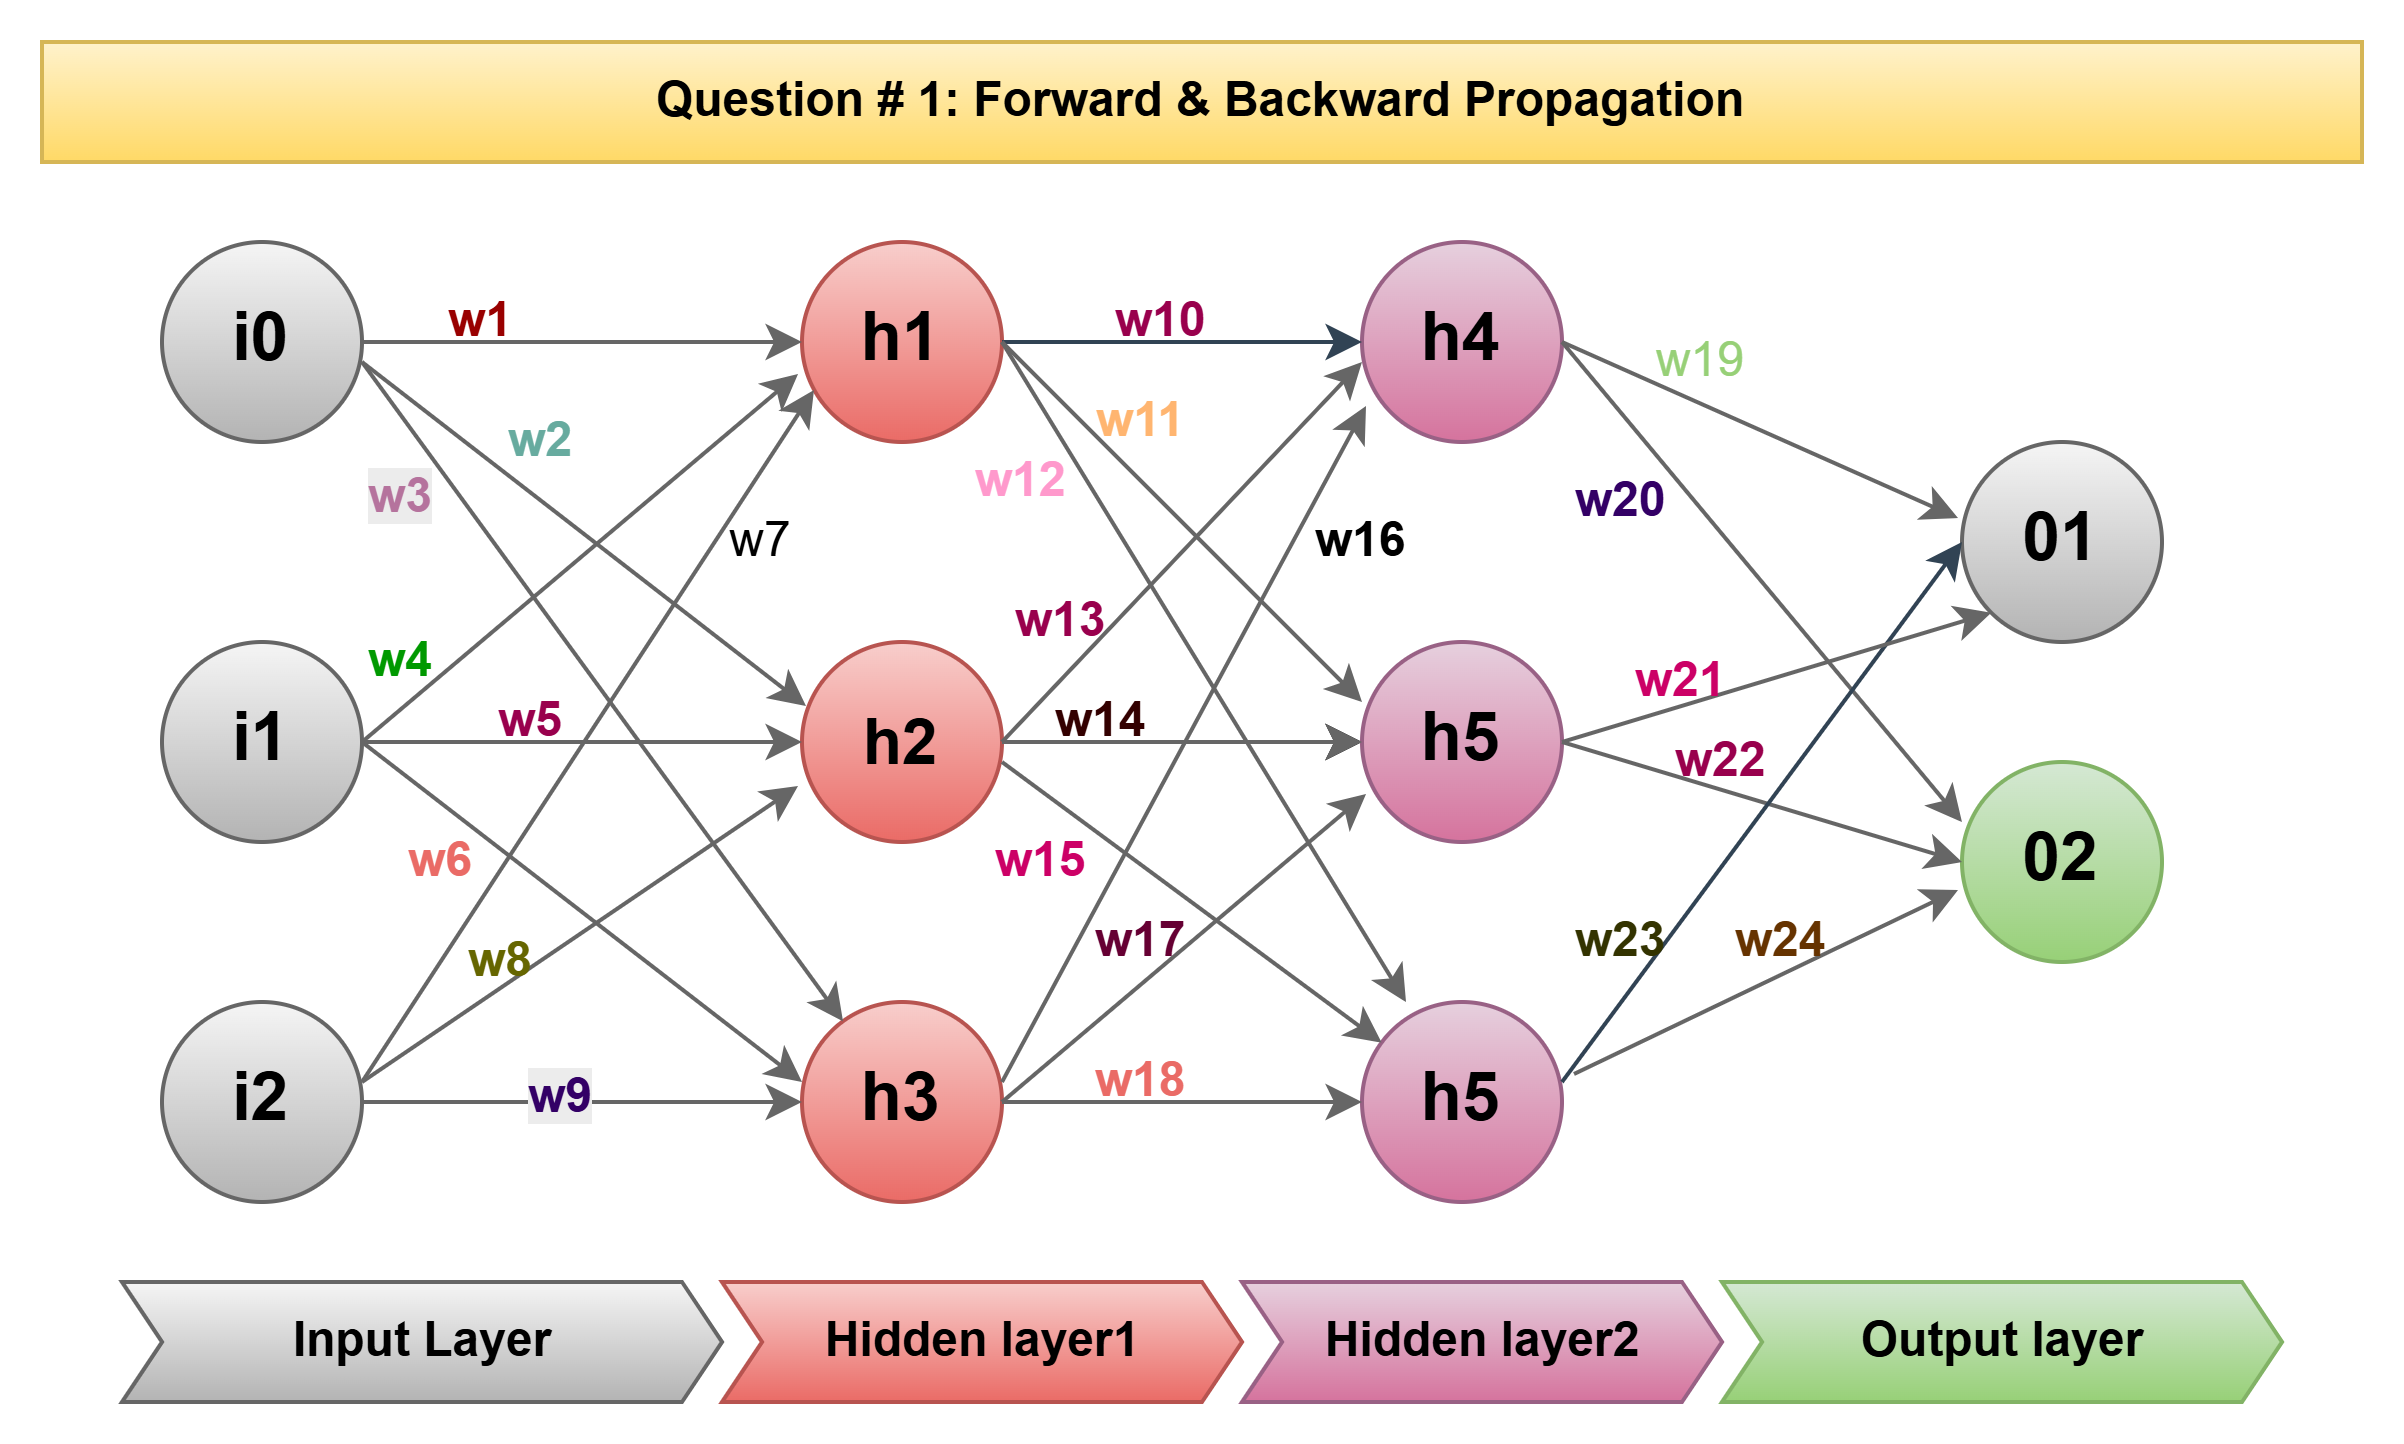


In [2]:
# Import Libraries
import numpy as np

In [3]:
# -----------------------------
#  Define Function for inputs
# -----------------------------
def INPUT():
    # -------- USER INPUT --------
    while True:
        try:
            i0 = float(input("Enter input i0: "))
            i1 = float(input("Enter input i1: "))
            i2 = float(input("Enter input i2: "))
            break   # exit loop if inputs are valid
        except ValueError:
            print("Invalid input! Please enter numeric values only.")
    X = np.array([[i0, i1, i2]], dtype=np.float32)
    return X

In [4]:
# -----------------------------
# Define Function for output
# -----------------------------
def Target_Output():
    while True:
        try:
            o1 = float(input("Enter target output o1: "))
            o2 = float(input("Enter target output o2: "))
            break   # exit loop if input is valid
        except ValueError:
            print("Invalid input! Please enter numeric values only.")
    y = np.array([[o1, o2]], dtype=np.float32)
    return y

In [5]:
# -----------------------------
# 1. Define Function for weight initialization and learning rate
# -----------------------------
def Weight_Initialization():
    # -------- WEIGHT INITIALIZATION --------
    np.random.seed(1)
    # Initialize weights and fix floating point precision to float32
    W1 = np.random.randn(3, 3).astype(np.float32)   # Input -> Hidden1
    W2 = np.random.randn(3, 3).astype(np.float32)   # Hidden1 -> Hidden2
    W3 = np.random.randn(3, 2).astype(np.float32)   # Hidden2 -> Output
    # Round weights to 1 decimal place
    W1 = np.round(W1, 1)
    W2 = np.round(W2, 1)
    W3 = np.round(W3, 1)
    # Get learning rate from user
    learning_rate = float(input("Enter Learning rate value: "))
    lr = learning_rate
    # Return weights and learning rate
    return W1, W2, W3, lr

In [6]:
# --------------------------------------------
# Bias initialization function
# --------------------------------------------
def Bias_Initialization():

    # Random biases between -0.1 and 0.1
    b1 = np.round(np.random.uniform(-0.1,0.1,(1,3)),1)
    b2 = np.round(np.random.uniform(-0.1,0.1,(1,3)),1)
    b3 = np.round(np.random.uniform(-0.1,0.1,(1,2)),1)

    # return biases
    return b1, b2, b3

In [7]:
# ============================================
# 3. Activation functions
# ============================================
# ReLU activation
# ReLU(z) = max(0, z)
def relu(x):
    return np.maximum(0, x)
# ReLU derivative
# ReLU'(z) = 1 if z>0 else 0
def relu_derivative(x):
    return (x > 0).astype(float)
# Sigmoid activation
# σ(z) = 1 / (1 + e^-z)
def sigmoid(x):
    return 1 / (1 + np.exp(-x))
# Sigmoid derivative
# σ'(z) = a(1-a)
# where a = sigmoid(z)
def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=0, keepdims=True))  # stability
    return exp_z / np.sum(exp_z, axis=0, keepdims=True)

## Method # 1: Implementation with numpy scalar code

In [8]:
# ============================================
# 1. Inputs and target
# ============================================
x = np.array([0.5,0.1,0.2])
y = np.array([1,0])

In [9]:
# ============================================
# 2. Initialize weights randomly
# --------------------------------------------
# Input layer (3 neurons) -> Hidden layer 1 (3 neurons)
w1, w2, w3 = np.round(np.random.rand(3),1)
w4, w5, w6 = np.round(np.random.rand(3),1)
w7, w8, w9 = np.round(np.random.rand(3),1)

# Hidden layer 1 (3 neurons) -> Hidden layer 2 (3 neurons)
w10, w11, w12 = np.round(np.random.rand(3),1)
w13, w14, w15 = np.round(np.random.rand(3),1)
w16, w17, w18 = np.round(np.random.rand(3),1)

# Hidden layer 2 (3 neurons) -> Output layer (2 neurons)
w19, w20 = np.round(np.random.rand(2),1)
w21, w22 = np.round(np.random.rand(2),1)
w23, w24 = np.round(np.random.rand(2),1)

# Get learning rate from user
learning_rate = float(input("Enter Learning rate value: "))
lr = learning_rate

Enter Learning rate value: 0.01


In [10]:
# -------------------------
# Initialize biases for each layer
# -------------------------
# Hidden layer 1 biases
b1 = np.round(np.random.uniform(-0.1, 0.1), 2)
b2 = np.round(np.random.uniform(-0.1, 0.1), 2)
b3 = np.round(np.random.uniform(-0.1, 0.1), 2)

# Hidden layer 2 biases
b4 = np.round(np.random.uniform(-0.1, 0.1), 2)
b5 = np.round(np.random.uniform(-0.1, 0.1), 2)
b6 = np.round(np.random.uniform(-0.1, 0.1), 2)

# Output layer biases
b7 = np.round(np.random.uniform(-0.1, 0.1), 2)
b8 = np.round(np.random.uniform(-0.1, 0.1), 2)

# Print initial biases
print("Initial biases:")
print("Hidden layer 1:", b1, b2, b3)
print("Hidden layer 2:", b4, b5, b6)
print("Output layer:", b7, b8)

Initial biases:
Hidden layer 1: 0.05 0.02 0.1
Hidden layer 2: 0.02 0.05 -0.01
Output layer: -0.08 -0.01


In [15]:
for epoch in range(100):

    # -------------------------
    # Forward Pass
    # -------------------------
    sumh1 = w1*x[0] + w2*x[1] + w3*x[2] + b1
    sumh2 = w4*x[0] + w5*x[1] + w6*x[2] + b2
    sumh3 = w7*x[0] + w8*x[1] + w9*x[2] + b3

    outputh1 = relu(sumh1)
    outputh2 = relu(sumh2)
    outputh3 = relu(sumh3)

    sumh4 = w10*outputh1 + w11*outputh2 + w12*outputh3 + b4
    sumh5 = w13*outputh1 + w14*outputh2 + w15*outputh3 + b5
    sumh6 = w16*outputh1 + w17*outputh2 + w18*outputh3 + b6

    outputh4 = relu(sumh4)
    outputh5 = relu(sumh5)
    outputh6 = relu(sumh6)

    sumo1 = w19*outputh4 + w21*outputh5 + w23*outputh6 + b7
    sumo2 = w20*outputh4 + w22*outputh5 + w24*outputh6 + b8

    outputo1 = sigmoid(sumo1)
    outputo2 = sigmoid(sumo2)

    # -------------------------
    # Loss
    # -------------------------
    loss = 0.5*(outputo1 - y[0])**2 + 0.5*(outputo2 - y[1])**2

    # -------------------------
    # Backpropagation
    # -------------------------

    dL_doutputo1 = (outputo1 - y[0])
    dL_doutputo2 = (outputo2 - y[1])

    doutputo1_dsumo1 = sigmoid_derivative(outputo1)
    doutputo2_dsumo2 = sigmoid_derivative(outputo2)

    # -------- Output layer --------
    grad_w19 = dL_doutputo1 * doutputo1_dsumo1 * outputh4
    grad_w21 = dL_doutputo1 * doutputo1_dsumo1 * outputh5
    grad_w23 = dL_doutputo1 * doutputo1_dsumo1 * outputh6

    grad_w20 = dL_doutputo2 * doutputo2_dsumo2 * outputh4
    grad_w22 = dL_doutputo2 * doutputo2_dsumo2 * outputh5
    grad_w24 = dL_doutputo2 * doutputo2_dsumo2 * outputh6

    grad_b7 = dL_doutputo1 * doutputo1_dsumo1
    grad_b8 = dL_doutputo2 * doutputo2_dsumo2

    # -------- Hidden layer 2 --------

    # h4 contributions
    dsumo1_dh4 = w19
    dsumo2_dh4 = w20
    dh4_dsumh4 = relu_derivative(sumh4)

    grad_w10 = (dL_doutputo1*doutputo1_dsumo1*dsumo1_dh4 +
                dL_doutputo2*doutputo2_dsumo2*dsumo2_dh4) * dh4_dsumh4 * outputh1

    grad_w11 = (dL_doutputo1*doutputo1_dsumo1*dsumo1_dh4 +
                dL_doutputo2*doutputo2_dsumo2*dsumo2_dh4) * dh4_dsumh4 * outputh2

    grad_w12 = (dL_doutputo1*doutputo1_dsumo1*dsumo1_dh4 +
                dL_doutputo2*doutputo2_dsumo2*dsumo2_dh4) * dh4_dsumh4 * outputh3

    # h5 contributions
    dsumo1_dh5 = w21
    dsumo2_dh5 = w22
    dh5_dsumh5 = relu_derivative(sumh5)

    grad_w13 = (dL_doutputo1*doutputo1_dsumo1*dsumo1_dh5 +
                dL_doutputo2*doutputo2_dsumo2*dsumo2_dh5) * dh5_dsumh5 * outputh1

    grad_w14 = (dL_doutputo1*doutputo1_dsumo1*dsumo1_dh5 +
                dL_doutputo2*doutputo2_dsumo2*dsumo2_dh5) * dh5_dsumh5 * outputh2

    grad_w15 = (dL_doutputo1*doutputo1_dsumo1*dsumo1_dh5 +
                dL_doutputo2*doutputo2_dsumo2*dsumo2_dh5) * dh5_dsumh5 * outputh3

    # h6 contributions
    dsumo1_dh6 = w23
    dsumo2_dh6 = w24
    dh6_dsumh6 = relu_derivative(sumh6)

    grad_w16 = (dL_doutputo1*doutputo1_dsumo1*dsumo1_dh6 +
                dL_doutputo2*doutputo2_dsumo2*dsumo2_dh6) * dh6_dsumh6 * outputh1

    grad_w17 = (dL_doutputo1*doutputo1_dsumo1*dsumo1_dh6 +
                dL_doutputo2*doutputo2_dsumo2*dsumo2_dh6) * dh6_dsumh6 * outputh2

    grad_w18 = (dL_doutputo1*doutputo1_dsumo1*dsumo1_dh6 +
                dL_doutputo2*doutputo2_dsumo2*dsumo2_dh6) * dh6_dsumh6 * outputh3

    # biases hidden layer 2
    grad_b4 = (dL_doutputo1*doutputo1_dsumo1*dsumo1_dh4 +
               dL_doutputo2*doutputo2_dsumo2*dsumo2_dh4) * dh4_dsumh4

    grad_b5 = (dL_doutputo1*doutputo1_dsumo1*dsumo1_dh5 +
               dL_doutputo2*doutputo2_dsumo2*dsumo2_dh5) * dh5_dsumh5

    grad_b6 = (dL_doutputo1*doutputo1_dsumo1*dsumo1_dh6 +
               dL_doutputo2*doutputo2_dsumo2*dsumo2_dh6) * dh6_dsumh6

    # -------- Hidden layer 1 --------
    common_h4 = (dL_doutputo1*doutputo1_dsumo1*w19 +
                 dL_doutputo2*doutputo2_dsumo2*w20) * relu_derivative(sumh4)

    common_h5 = (dL_doutputo1*doutputo1_dsumo1*w21 +
                 dL_doutputo2*doutputo2_dsumo2*w22) * relu_derivative(sumh5)

    common_h6 = (dL_doutputo1*doutputo1_dsumo1*w23 +
                 dL_doutputo2*doutputo2_dsumo2*w24) * relu_derivative(sumh6)

    grad_w1 = (common_h4*w10 + common_h5*w13 + common_h6*w16) * relu_derivative(sumh1) * x[0]
    grad_w2 = (common_h4*w10 + common_h5*w13 + common_h6*w16) * relu_derivative(sumh1) * x[1]
    grad_w3 = (common_h4*w10 + common_h5*w13 + common_h6*w16) * relu_derivative(sumh1) * x[2]

    grad_w4 = (common_h4*w11 + common_h5*w14 + common_h6*w17) * relu_derivative(sumh2) * x[0]
    grad_w5 = (common_h4*w11 + common_h5*w14 + common_h6*w17) * relu_derivative(sumh2) * x[1]
    grad_w6 = (common_h4*w11 + common_h5*w14 + common_h6*w17) * relu_derivative(sumh2) * x[2]

    grad_w7 = (common_h4*w12 + common_h5*w15 + common_h6*w18) * relu_derivative(sumh3) * x[0]
    grad_w8 = (common_h4*w12 + common_h5*w15 + common_h6*w18) * relu_derivative(sumh3) * x[1]
    grad_w9 = (common_h4*w12 + common_h5*w15 + common_h6*w18) * relu_derivative(sumh3) * x[2]

    grad_b1 = relu_derivative(sumh1) * (common_h4*w10 + common_h5*w13 + common_h6*w16)
    grad_b2 = relu_derivative(sumh2) * (common_h4*w11 + common_h5*w14 + common_h6*w17)
    grad_b3 = relu_derivative(sumh3) * (common_h4*w12 + common_h5*w15 + common_h6*w18)

    # -------------------------
    # Update
    # -------------------------
    w1 -= lr*grad_w1; w2 -= lr*grad_w2; w3 -= lr*grad_w3
    w4 -= lr*grad_w4; w5 -= lr*grad_w5; w6 -= lr*grad_w6
    w7 -= lr*grad_w7; w8 -= lr*grad_w8; w9 -= lr*grad_w9

    w10 -= lr*grad_w10; w11 -= lr*grad_w11; w12 -= lr*grad_w12
    w13 -= lr*grad_w13; w14 -= lr*grad_w14; w15 -= lr*grad_w15
    w16 -= lr*grad_w16; w17 -= lr*grad_w17; w18 -= lr*grad_w18

    w19 -= lr*grad_w19; w20 -= lr*grad_w20
    w21 -= lr*grad_w21; w22 -= lr*grad_w22
    w23 -= lr*grad_w23; w24 -= lr*grad_w24

    b1 -= lr*grad_b1; b2 -= lr*grad_b2; b3 -= lr*grad_b3
    b4 -= lr*grad_b4; b5 -= lr*grad_b5; b6 -= lr*grad_b6
    b7 -= lr*grad_b7; b8 -= lr*grad_b8

    # PRINT
    if epoch % 10 == 0:

        print(f"\n================ Epoch {epoch} ================")
        print(f"Loss: {loss:.6f}")

        print("\n--- Gradients ---")
        print("w1–w3:", grad_w1, grad_w2, grad_w3)
        print("w4–w6:", grad_w4, grad_w5, grad_w6)
        print("w7–w9:", grad_w7, grad_w8, grad_w9)

        print("w10–w12:", grad_w10, grad_w11, grad_w12)
        print("w13–w15:", grad_w13, grad_w14, grad_w15)
        print("w16–w18:", grad_w16, grad_w17, grad_w18)

        print("w19–w24:", grad_w19, grad_w20, grad_w21, grad_w22, grad_w23, grad_w24)

        print("\n--- Updated Weights ---")
        print("w1–w3:", w1, w2, w3)
        print("w4–w6:", w4, w5, w6)
        print("w7–w9:", w7, w8, w9)

        print("w10–w12:", w10, w11, w12)
        print("w13–w15:", w13, w14, w15)
        print("w16–w18:", w16, w17, w18)

        print("w19–w24:", w19, w20, w21, w22, w23, w24)

        print("\nBiases:")
        print("b1:", b1, "b2:", b2, "b3:", b3)
        print("b4:", b4, "b5:", b5, "b6:", b6)
        print("b7:", b7, "b8:", b8)


================ Epoch 0 ================
Loss: 0.209569

--- Gradients ---
w1–w3: -0.003763170878056 -0.0007526341756112 -0.0015052683512224
w4–w6: -0.007011931110179353 -0.0014023862220358708 -0.0028047724440717417
w7–w9: -0.0026947993746130553 -0.0005389598749226111 -0.0010779197498452223
w10–w12: -0.010886198042735735 -0.016923474689304385 -0.008669031964829446
w13–w15: 0.007507487841234709 0.01167099661081191 0.005978455638574497
w16–w18: -0.002294381919548453 -0.0035668021278545494 -0.0018270906079432157
w19–w24: -0.03945052056892077 0.058613318902721534 -0.033047869794021474 0.04910062790954927 -0.02990551420596482 0.044431896355887235

--- Updated Weights ---
w1–w3: 0.10102672241708792 0.7002053444834174 0.500410688966835
w4–w6: 0.4053526721531705 0.501070534430634 0.7021410688612678
w7–w9: 0.09889526287708446 0.4997790525754167 0.09955810515083385
w10–w12: 0.3103482764884555 0.41594884353567446 0.7083063726389824
w13–w15: 0.3908891030018453 0.18597182958390884 0.8926798788225

In [17]:
# ============================================
# 5. Final predicted outputs
# ============================================
print("Predicted outputs after training:",outputo1,outputo2)

Predicted outputs after training: 0.676419339988378 0.4911828908033426


## Method # 2: Implementation with numpy vectorization code

In [18]:
# ============================================
# 1. Inputs and target
# ============================================
X=INPUT()
print(X)
# input target lable
y=Target_Output()
print(y)

Enter input i0: 0.1
Enter input i1: 0.2
Enter input i2: 0.3
[[0.1 0.2 0.3]]
Enter target output o1: 1
Enter target output o2: 2
[[1. 2.]]


In [26]:
x = np.array(X, dtype=float).reshape(3,)
y = np.array(y, dtype=float).reshape(2,)

In [19]:
# ============================================
# 2. Initialize weights
# ============================================
# eandomly initialize weights and lr as input
W1, W2, W3 , lr= Weight_Initialization()
print("W1:", W1)
print("W2:", W2)
print("W3:", W3)
print("W3:", lr)

Enter Learning rate value: 0.01
W1: [[ 1.6 -0.6 -0.5]
 [-1.1  0.9 -2.3]
 [ 1.7 -0.8  0.3]]
W2: [[-0.2  1.5 -2.1]
 [-0.3 -0.4  1.1]
 [-1.1 -0.2 -0.9]]
W3: [[ 0.   0.6]
 [-1.1  1.1]
 [ 0.9  0.5]]
W3: 0.01


In [20]:
# ============================================
# 3. Initialize Biases
# ============================================
# eandomly initialize weights and lr as input
b1,b2,b3= Bias_Initialization()
print("B1:", b1)
print("B2:", b2)
print("B3:", b3)

B1: [[-0.1  0.1  0.1]]
B2: [[ 0.  -0.   0.1]]
B3: [[-0.1 -0. ]]


In [27]:
# -------------------------
# TRAINING LOOP
# -------------------------

for epoch in range(100):

    # =========================
    # FORWARD PASS
    # =========================

    z1 = np.dot(x, W1) + b1
    outputh1 = relu(z1).reshape(3,)

    z2 = np.dot(outputh1, W2) + b2
    outputh2 = relu(z2).reshape(3,)

    z3 = np.dot(outputh2, W3) + b3
    outputo = sigmoid(z3).reshape(2,)

    # =========================
    # LOSS
    # =========================

    loss = 0.5 * np.sum((outputo - y) ** 2)

    # =========================
    # BACKPROP (STABLE)
    # =========================

    # Output layer error
    delta3 = (outputo - y) * sigmoid_derivative(outputo)
    delta3 = delta3.reshape(2,)

    dW3 = np.outer(outputh2, delta3)
    db3 = delta3

    # Hidden layer 2
    delta2 = np.dot(W3, delta3) * relu_derivative(outputh2)
    delta2 = delta2.reshape(3,)

    dW2 = np.outer(outputh1, delta2)
    db2 = delta2

    # Hidden layer 1
    delta1 = np.dot(W2, delta2) * relu_derivative(outputh1)
    delta1 = delta1.reshape(3,)

    dW1 = np.outer(x, delta1)
    db1 = delta1

    # =========================
    # UPDATE
    # =========================

    W3 -= lr * dW3
    b3 -= lr * db3

    W2 -= lr * dW2
    b2 -= lr * db2

    W1 -= lr * dW1
    b1 -= lr * db1

    # =========================
    # PRINT
    # =========================

    if epoch % 10 == 0:
        print(f"\nEpoch {epoch}")
        print("Loss:", loss)
        print("Output:", outputo)


Epoch 0
Loss: 4.4894989941944956e-07
Output: [6.35793743e-04 9.99297386e-01]

Epoch 10
Loss: 4.4662573069368625e-07
Output: [6.34112474e-04 9.99299177e-01]

Epoch 20
Loss: 4.443163186435747e-07
Output: [6.32437298e-04 9.99300961e-01]

Epoch 30
Loss: 4.42020192656997e-07
Output: [6.30768854e-04 9.99302740e-01]

Epoch 40
Loss: 4.3974280575375085e-07
Output: [6.29111073e-04 9.99304511e-01]

Epoch 50
Loss: 4.374845790402531e-07
Output: [6.27462959e-04 9.99306271e-01]

Epoch 60
Loss: 4.352386139950153e-07
Output: [6.25819353e-04 9.99308026e-01]

Epoch 70
Loss: 4.330114333624039e-07
Output: [6.24182832e-04 9.99309769e-01]

Epoch 80
Loss: 4.308017837436631e-07
Output: [6.22556893e-04 9.99311504e-01]

Epoch 90
Loss: 4.286075807915678e-07
Output: [6.20939004e-04 9.99313232e-01]


In [ ]:
# ============================================
# 5. Final prediction
# ============================================

print("Predicted outputs after training:", a3)

## Method 3: Implementation with Tensorflow library

In [28]:
# Import TensorFlow library for building neural networks
import tensorflow as tf
import numpy as np

In [29]:
# -----------------------------
# 1. Define Input Data
# -----------------------------
X=INPUT()
print(X)

Enter input i0: 0.1
Enter input i1: 0.2
Enter input i2: 0.3
[[0.1 0.2 0.3]]


In [30]:
# input target lable
y=Target_Output()
print(y)

Enter target output o1: 1
Enter target output o2: 2
[[1. 2.]]


In [31]:
# -----------------------------
# 2. Define Neural Network Architecture
# -----------------------------

# Sequential model means layers are stacked one after another
model = tf.keras.Sequential([

    # First Dense layer (Hidden Layer 1)
    # units=3 → number of neurons (h1,h2,h3)
    # activation='sigmoid' → activation function
    # input_shape=(3,) → network expects 3 input features
    tf.keras.layers.Dense(3, activation='relu', input_shape=(3,)),
    # Second Dense layer (Hidden Layer 2)
    # 3 neurons (h4,h5,h6)
    # receives output from previous layer
    tf.keras.layers.Dense(3, activation='relu'),
    # Output layer
    # 2 neurons corresponding to outputs (o1,o2)
    tf.keras.layers.Dense(2, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [32]:
for layer in model.layers:
    print(layer.get_weights())

[array([[-0.5545397 ,  0.72349906, -0.5911701 ],
       [ 0.7754507 ,  0.8149202 ,  0.73733807],
       [-0.08890033, -0.81416535,  0.01119232]], dtype=float32), array([0., 0., 0.], dtype=float32)]
[array([[ 0.694865  , -0.9283259 , -0.90171313],
       [-0.0839684 , -0.5441649 , -0.50733995],
       [-0.45850658, -0.296901  , -0.16565132]], dtype=float32), array([0., 0., 0.], dtype=float32)]
[array([[-0.16219223, -0.44018245],
       [ 0.3115741 , -0.1178022 ],
       [ 0.3167354 , -0.7586385 ]], dtype=float32), array([0., 0.], dtype=float32)]


In [33]:
model.compile(
    # Optimizer controls how weights are updated
    # SGD = Stochastic Gradient Descent
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    # Loss function measures prediction error
    # MSE = Mean Squared Error
    loss='mse'
)

In [34]:
# model.fit performs the training process
model.fit(
    X,          # input data
    y,          # true target labels
    epochs=5,   # number of training iterations
    verbose=0       # suppress training output
    )

In [35]:
# -----------------------------
# 5. Make Prediction
# -----------------------------
# After training, the model predicts output for the same input
prediction = model.predict(X)
# Print predicted values
print(prediction) #  [[output1  output2]]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
[[0.501561  0.5046825]]


## Method 3: Implementation with Pytorch library

In [36]:
# Import the PyTorch library (main deep learning framework)
import torch
# Import neural network module from PyTorch
# This provides layers, activation functions, and loss functions
import torch.nn as nn
# Import optimization algorithms such as SGD, Adam etc.
import torch.optim as optim

In [37]:
# -----------------------------
# 1. Define Input Data
# -----------------------------
X=INPUT()
# Convert input to PyTorch tensor
X = torch.tensor(X, dtype=torch.float32)
print(X)

Enter input i0: 0.1
Enter input i1: 0.2
Enter input i2: 0.3
tensor([[0.1000, 0.2000, 0.3000]])


In [38]:
# input target lable
y=Target_Output()
y = torch.tensor(y, dtype=torch.float32)
print(y)

Enter target output o1: 1
Enter target output o2: 2
tensor([[1., 2.]])


In [43]:
# -----------------------------
# 2. Define Neural Network Model
# -----------------------------
# nn.Sequential means layers are arranged sequentially
# The output of one layer becomes the input of the next layer
model = nn.Sequential(
    # First fully connected layer
    # 3 input features → 3 neurons in hidden layer 1 (h1,h2,h3)
    nn.Linear(3,3),
    # Relu activation function applied to hidden layer 1
    nn.ReLU(),
    # Second fully connected layer
    # 3 neurons → 3 neurons in hidden layer 2 (h4,h5,h6)
    nn.Linear(3,3),
    # Relu activation for hidden layer 2
    nn.ReLU(),
    # Output layer
    # 3 neurons → 2 output neurons (o1,o2)
    nn.Linear(3,2),
    # Sigmoid activation for output layer
    nn.Sigmoid()
)


In [44]:
# -----------------------------
# 3. Define Loss Function
# -----------------------------
# Mean Squared Error (MSE) measures difference
# between predicted output and actual output
criterion = nn.MSELoss()

In [45]:
# -----------------------------
# 4. Define Optimizer
# -----------------------------
# Stochastic Gradient Descent optimizer
# model.parameters() returns all weights and biases
# lr = learning rate controlling step size during updates
optimizer = optim.SGD(model.parameters(), lr=0.1)


In [46]:
## print weights and biases
for name, param in model.named_parameters():
    print(name)
    print(param)

0.weight
Parameter containing:
tensor([[-0.5564,  0.1185,  0.4835],
        [-0.1229, -0.3893,  0.3703],
        [ 0.1992, -0.5528, -0.4742]], requires_grad=True)
0.bias
Parameter containing:
tensor([-0.2535,  0.3819, -0.1233], requires_grad=True)
2.weight
Parameter containing:
tensor([[ 0.3020, -0.0578,  0.1411],
        [-0.3819, -0.0508,  0.0861],
        [-0.0193,  0.3934,  0.4446]], requires_grad=True)
2.bias
Parameter containing:
tensor([0.3103, 0.2248, 0.0894], requires_grad=True)
4.weight
Parameter containing:
tensor([[ 0.3622,  0.1873, -0.4629],
        [-0.2840, -0.1833, -0.4582]], requires_grad=True)
4.bias
Parameter containing:
tensor([-0.5629,  0.4573], requires_grad=True)


In [47]:
# -----------------------------
# 5. Training Loop
# -----------------------------
# Train the model for 10,000 iterations
for epoch in range(100):
    # -------- Forward Propagation --------
    # Pass input through the network to get predicted output
    y_pred = model(X)
    # -------- Compute Loss --------
    # Calculate error between predicted output and true output
    loss = criterion(y_pred, y)
    # -------- Reset Gradients --------
    # Clear gradients from previous iteration
    # (PyTorch accumulates gradients by default)
    optimizer.zero_grad()
    # -------- Backpropagation --------
    # Compute gradients of loss with respect to all weights
    # using automatic differentiation
    loss.backward()
    # -------- Update Weights --------
    # Optimizer updates weights using computed gradients
    optimizer.step()
    # Print loss every 1000 iterations to monitor training
    if epoch % 100 == 0:
        print("Loss:", loss.item())


Loss: 1.241556167602539


In [48]:
## print gradients after back propagation
for name, param in model.named_parameters():
    print(name, param.grad)

0.weight tensor([[ 0.0000,  0.0000,  0.0000],
        [-0.0006, -0.0012, -0.0018],
        [ 0.0000,  0.0000,  0.0000]])
0.bias tensor([ 0.0000, -0.0059,  0.0000])
2.weight tensor([[-0.0000, -0.0183, -0.0000],
        [-0.0000, -0.0115, -0.0000],
        [ 0.0000,  0.0000,  0.0000]])
2.bias tensor([-0.0571, -0.0359,  0.0000])
4.weight tensor([[-0.0323, -0.0206, -0.0000],
        [-0.0547, -0.0348, -0.0000]])
4.bias tensor([-0.0407, -0.0689])


In [ ]:
# -----------------------------
# 6. Final Prediction
# -----------------------------
# Run the trained model on input data again
# detach() removes tensor from computation graph
print("Prediction:", model(X).detach())

# Question # 2:

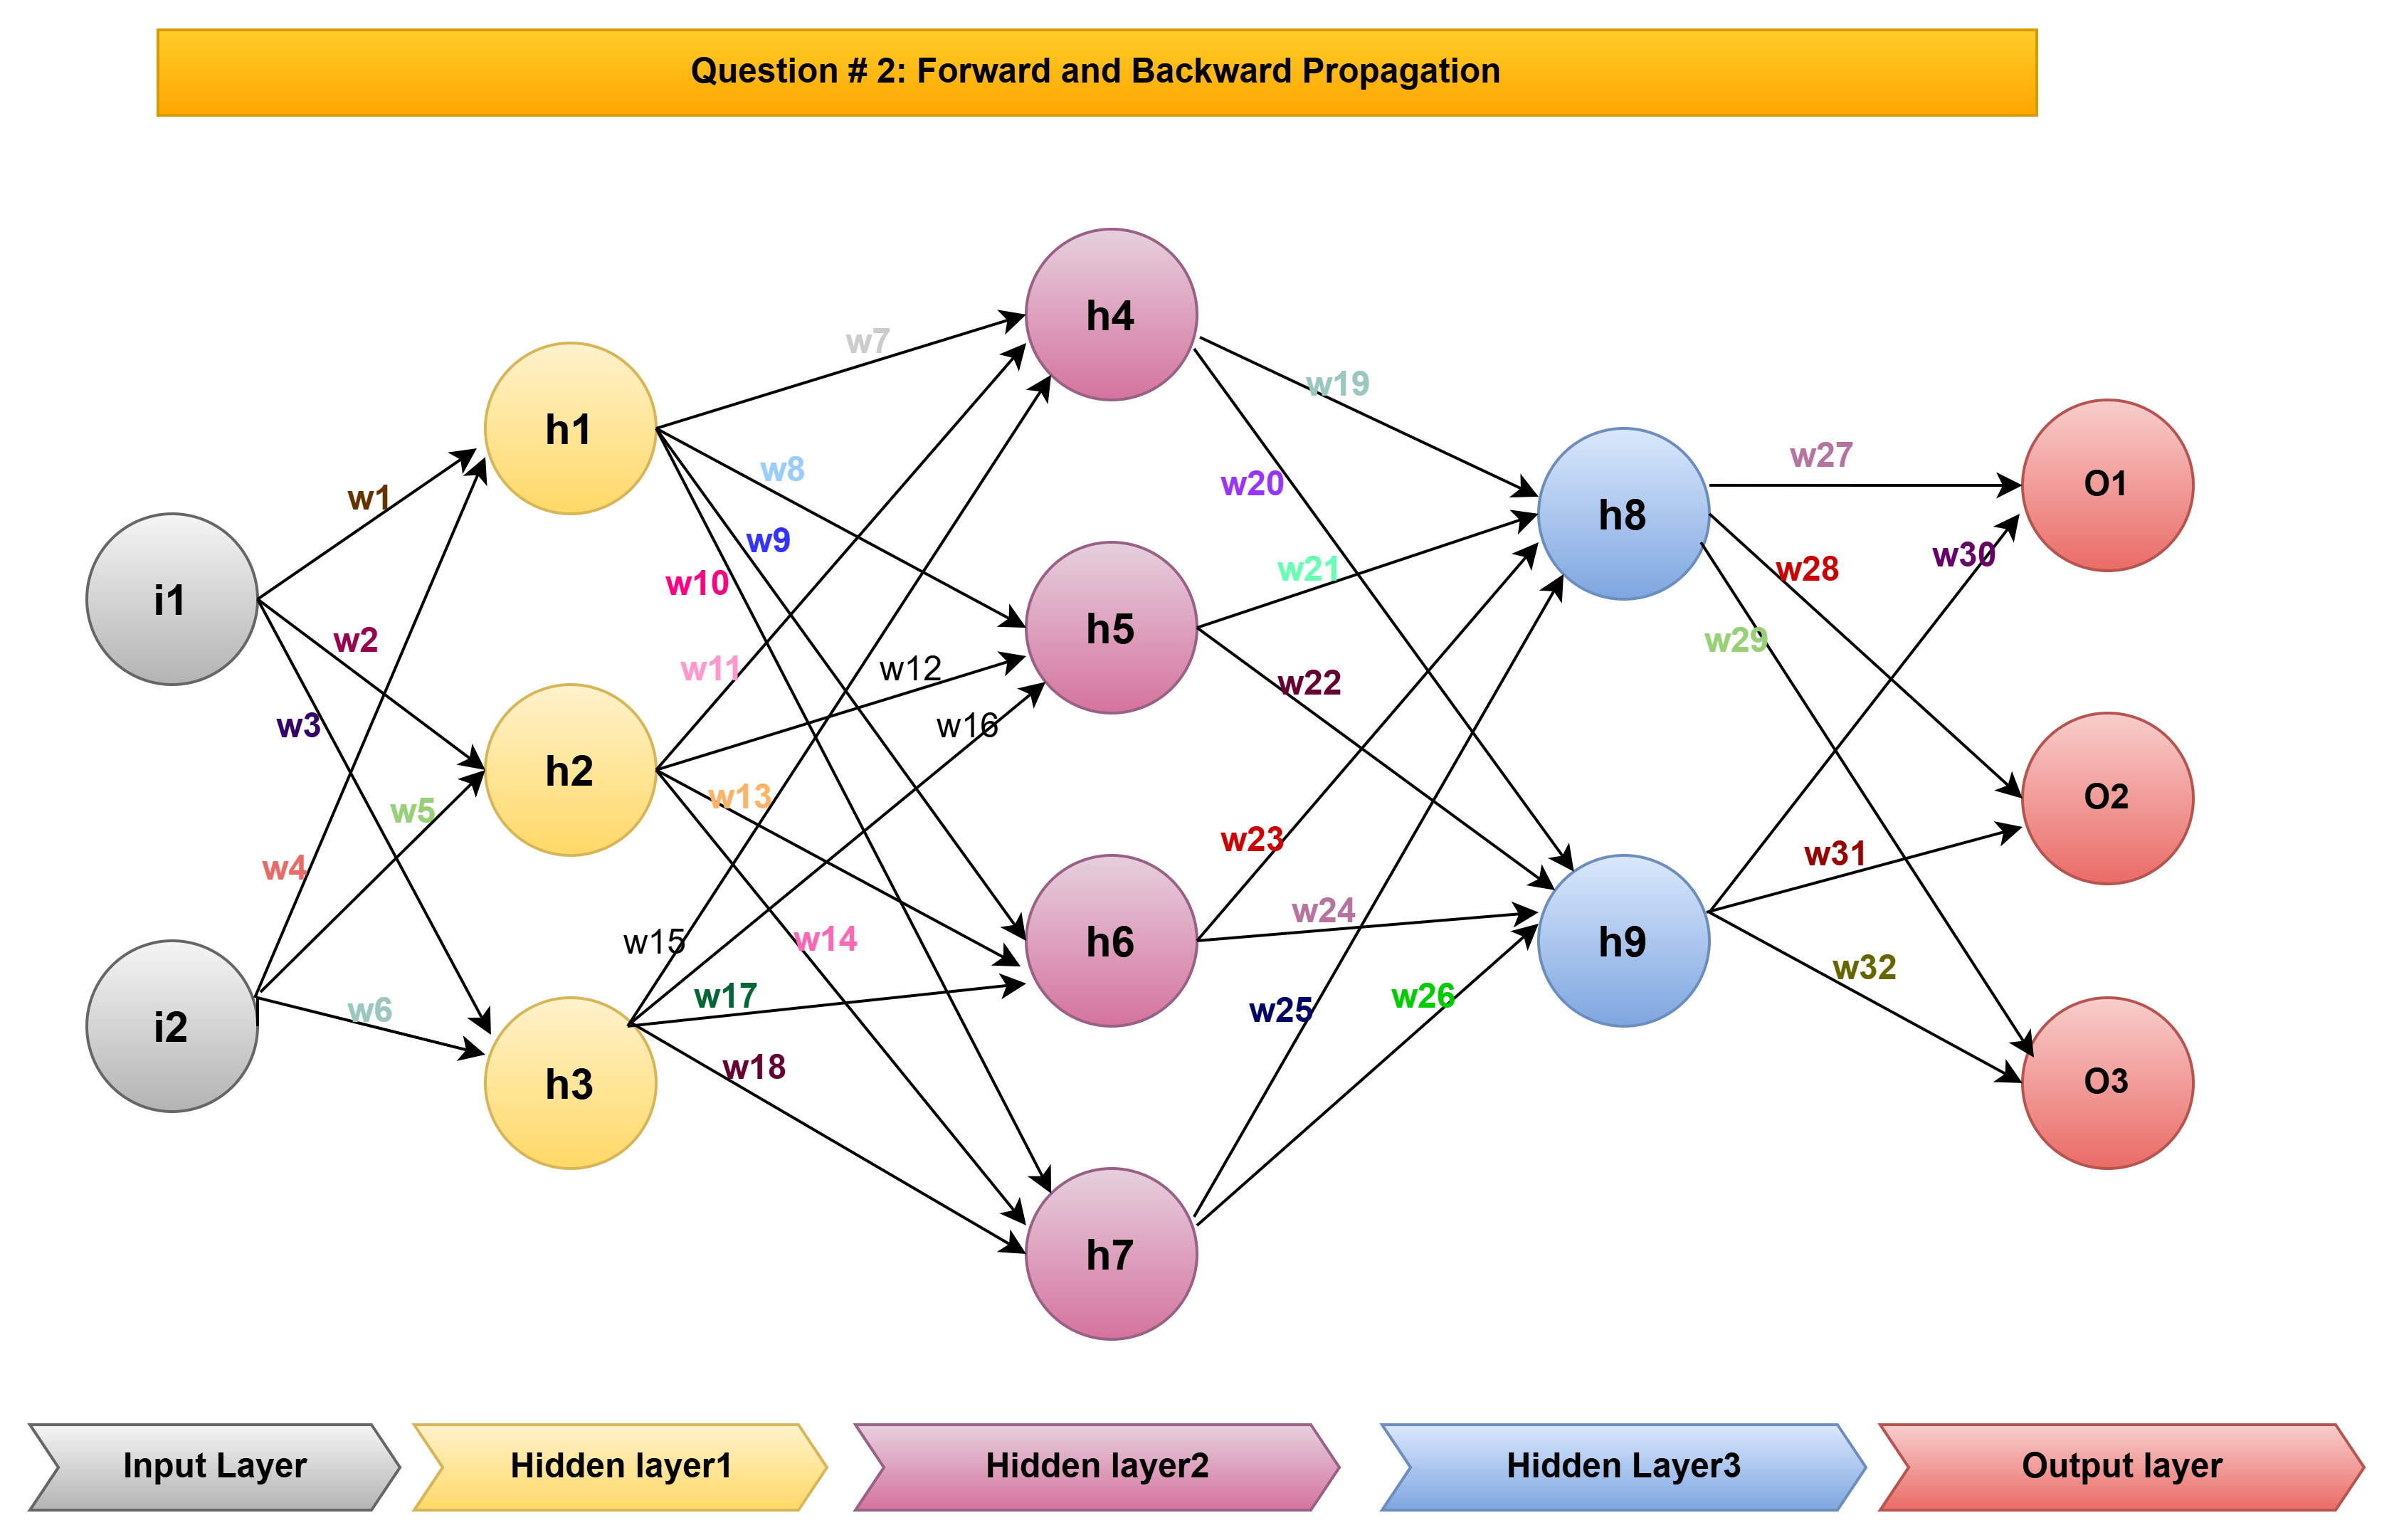

In [49]:
# -----------------------------
# Define Function for inputs & target
# -----------------------------
def UserInputs(num_features=2, num_classes=3):

    # -------- USER INPUT FOR FEATURES --------
    global features  # allow modification of the global variable
    while True:
        try:
            features = [] # reset
            for i in range(num_features):
                val = float(input(f"Enter input i{i}: "))
                features.append(val)
            break
        except ValueError:
            print("Invalid input! Please enter numeric values only.")

    X = np.array([features], dtype=np.float32)

    # -------- USER INPUT FOR TARGET CLASS --------
    while True:
        try:
            class_index = int(input(f"Enter target class (0 to {num_classes-1}): "))
            if 0 <= class_index < num_classes:
                break
            else:
                print(f"Invalid class! Enter a number between 0 and {num_classes-1}.")
        except ValueError:
            print("Invalid input! Please enter an integer.")

    # One-hot encode the target
    y = np.zeros((1, num_classes), dtype=np.float32)
    y[0, class_index] = 1.0

    return X, y


In [50]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

In [51]:
# -----------------------------
# Global variable
# -----------------------------
features = []      # store feature values
class_index = 0    # store class index globally

In [52]:
# -------------------------
# Build the model
# -------------------------
model = Sequential([
    # Input layer -> Hidden layer 1 (3 neurons, ReLU)
    Dense(3, activation='relu', input_shape=(2,), name='hidden1'),

    # Hidden layer 2 (4 neurons, ReLU)
    Dense(4, activation='relu', name='hidden2'),

    # Hidden layer 3 (3 neurons, ReLU)
    Dense(3, activation='relu', name='hidden3'),

    # Output layer (3 neurons, softmax for multiclass)
    Dense(3, activation='softmax', name='output')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [53]:
# -------------------------
# Compile the model
# -------------------------
# - Optimizer: Adam
# - Loss: categorical crossentropy for multiclass classification
# - Metrics: accuracy
model.compile(optimizer=Adam(learning_rate=0.01),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [54]:
X, y = UserInputs()
print("Input X:", X)
print("Target y (one-hot):", y)

Enter input i0: 0.1
Enter input i1: 0.2
Enter target class (0 to 2): 0.3
Invalid input! Please enter an integer.
Enter target class (0 to 2): 1
Input X: [[0.1 0.2]]
Target y (one-hot): [[0. 1. 0.]]


In [ ]:
# -------------------------
# Train the model
# -------------------------
# epochs=100, batch_size=1 (single sample in this example)
history = model.fit(X, y, epochs=100, batch_size=1, verbose=1)

In [ ]:
for layer in model.layers:
    print(layer.get_weights())

In [55]:
# -------------------------
# Make predictions
# -------------------------
pred = model.predict(X)
print("Predicted probabilities:", pred)
print("Predicted class:", np.argmax(pred, axis=1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Predicted probabilities: [[0.33118883 0.3347748  0.33403638]]
Predicted class: [1]


Method 1: Implementation in Pytorch

In [56]:
import torch                  # Import main PyTorch library (used for tensors and deep learning operations)

import torch.nn as nn        # Import neural network module from PyTorch (contains layers, loss functions, etc.)

import torch.optim as optim  # Import optimization algorithms (like SGD, Adam) used to train models

In [57]:
# global variable to store features
features = []

def User_Inputs(num_features=2, num_classes=3):  # Function to take user input (features + class label)

    global features  # Use the global 'features' list inside this function

    # -------- USER INPUT FOR FEATURES --------
    while True:  # Loop until valid input is entered
        try:
            features = []  # Reset features list each time

            for i in range(num_features):  # Loop for number of features
                val = float(input(f"Enter input i{i}: "))  # Take input and convert to float
                features.append(val)  # Add value to features list

            break  # Exit loop if all inputs are valid

        except ValueError:  # If user enters non-numeric value
            print("Invalid input! Please enter numeric values only.")  # Show error message

    X = torch.tensor([features], dtype=torch.float32)
    # Convert features list into PyTorch tensor
    # Shape = (1, num_features) → 1 sample with multiple features

    # -------- USER INPUT FOR TARGET CLASS --------
    while True:  # Loop until valid class is entered
        try:
            class_index = int(input(f"Enter target class (0 to {num_classes-1}): "))
            # Take class input as integer

            if 0 <= class_index < num_classes:  # Check if class is in valid range
                break  # Exit loop if valid
            else:
                print(f"Invalid class! Enter a number between 0 and {num_classes-1}.")
                # Show error if class is out of range

        except ValueError:  # If input is not an integer
            print("Invalid input! Please enter an integer.")  # Show error message

    y = torch.tensor([class_index], dtype=torch.long)
    # Convert class index to tensor (NOT one-hot encoding)
    # dtype long is required for classification tasks in PyTorch

    return X, y  # Return input features (X) and target label (y)

In [58]:
# -----------------------------
# Define the neural network
# -----------------------------
class MulticlassNN(nn.Module):  # Create a neural network class by inheriting nn.Module

    def __init__(self):  # Constructor method (runs when object is created)
        super(MulticlassNN, self).__init__()
        # Call parent class constructor (important for PyTorch models)

        self.hidden1 = nn.Linear(2, 3)
        # First layer: takes 2 input features → outputs 3 neurons (Input → Hidden1)

        self.hidden2 = nn.Linear(3, 4)
        # Second layer: takes 3 inputs → outputs 4 neurons (Hidden1 → Hidden2)

        self.hidden3 = nn.Linear(4, 3)
        # Third layer: takes 4 inputs → outputs 3 neurons (Hidden2 → Hidden3)

        self.output = nn.Linear(3, 3)
        # Output layer: takes 3 inputs → outputs 3 values (for 3 classes)

        self.relu = nn.ReLU()
        # ReLU activation function (adds non-linearity)

    def forward(self, x):  # Forward pass (how data moves through network)

        h1 = self.relu(self.hidden1(x))
        # Pass input through first layer, then apply ReLU activation

        h2 = self.relu(self.hidden2(h1))
        # Pass result of h1 into second layer, then apply ReLU

        h3 = self.relu(self.hidden3(h2))
        # Pass result of h2 into third layer, then apply ReLU

        out = self.output(h3)
        # Final output layer (no activation here → gives raw scores/logits)

        return out
        # Return final output (used for loss calculation, e.g., CrossEntropyLoss)

In [59]:
# -----------------------------
# Training setup
# -----------------------------
model = MulticlassNN()
# Create an object (instance) of your neural network class

criterion = nn.CrossEntropyLoss()
# Define loss function → used for multiclass classification
# It compares predicted output (logits) with true class label

optimizer = optim.Adam(model.parameters(), lr=0.01)
# Define optimizer (Adam)
# model.parameters() → all weights & biases to be updated
# lr=0.01 → learning rate (controls how fast model learns)

epochs = 50
# Number of times the model will go through the entire training data

In [60]:
# -----------------------------
# Function to get user input
# -----------------------------
X, y = User_Inputs()
print("Input X:", X)
print("Target y (class index):", y)

Enter input i0: 0.1
Enter input i1: 0.2
Enter target class (0 to 2): 0.3
Invalid input! Please enter an integer.
Enter target class (0 to 2): 1
Input X: tensor([[0.1000, 0.2000]])
Target y (class index): tensor([1])


In [61]:

# -----------------------------
# Training loop
# -----------------------------
for epoch in range(epochs):  # Loop through the dataset multiple times (epochs)

    optimizer.zero_grad()
    # Reset gradients to zero before each iteration (important to avoid accumulation)

    outputs = model(X)
    # Forward pass → send input X through the model to get predictions (logits)

    loss = criterion(outputs, y)
    # Compute loss → compare predicted outputs with true labels y

    loss.backward()
    # Backpropagation → calculate gradients of loss w.r.t. model parameters

    optimizer.step()
    # Update weights using calculated gradients (learning step)

    if epoch % 10 == 0:
        # Print results every 10 epochs for monitoring

        _, predicted = torch.max(outputs, 1)
        # Get predicted class → index of maximum value (highest probability/logit)

        print(f"Epoch {epoch}, Loss: {loss.item():.6f}, Predicted class: {predicted.item()}")
        # Print epoch number, loss value, and predicted class


Epoch 0, Loss: 1.456923, Predicted class: 2
Epoch 10, Loss: 1.150888, Predicted class: 2
Epoch 20, Loss: 0.945973, Predicted class: 1
Epoch 30, Loss: 0.751954, Predicted class: 1
Epoch 40, Loss: 0.553192, Predicted class: 1


In [62]:
# -----------------------------
# Final prediction
# -----------------------------
outputs = model(X)
# Pass input X through the trained model → get raw outputs (logits)

_, predicted = torch.max(outputs, 1)
# Find index of highest value in outputs → gives predicted class

print("Final predicted class:", predicted.item())
# Print the predicted class (convert tensor to normal value using .item())

print("Predicted probabilities:", torch.softmax(outputs, dim=1).detach().numpy())
# Apply softmax to convert logits into probabilities (values between 0 and 1)
# dim=1 → apply softmax across classes
# detach() → remove from computation graph (no gradient tracking)
# numpy() → convert tensor to NumPy array for easy display

Final predicted class: 1
Predicted probabilities: [[0.14473073 0.6861323  0.16913705]]


# Question # 5: Apply loss functions simle calculation for classification and Regression

### 1. Regression Loss Functions


**Example 1**: Predicting House Prices (MSE)


In [51]:
import numpy as np

In [52]:
# True house prices (in $1000s)
y_true = np.array([250, 300, 200, 400])
# Predicted house prices
y_pred = np.array([240, 310, 195, 390])

In [53]:
# Mean Squared Error
# Mean Squared Error
mse = np.mean((y_true - y_pred)**2)
print("Regression Example 1 - MSE:", round(mse, 2))

Regression Example 1 - MSE: 81.25


**Example 2:** Predicting Car Mileage (MAE)

In [54]:
# Mean Absolute Error
mae = np.mean(np.abs(y_true - y_pred))
print("Regression Example 2 - MAE:", round(mae, 2))

Regression Example 2 - MAE: 8.75


### 2. Classification Loss Functions

**Example 1:** Binary Classification (BCE)

Problem: Predict if email is spam (1) or not (0)

In [55]:
# True labels
y_true = np.array([1, 0, 1])
# Predicted probabilities
y_pred = np.array([0.9, 0.2, 0.6])

In [56]:
# Clip predictions to avoid log(0)
epsilon = 1e-15
y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

In [57]:
# Binary Cross-Entropy
bce_per_sample = - (y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
bce_avg = np.mean(bce_per_sample)
print("Classification Example 1 - BCE:", round(bce_avg, 3))

Classification Example 1 - BCE: 0.28


**Example 2:** Multi-Class Classification (CCE)

Problem: Predict handwritten digit (3 classes )

In [58]:
# True labels (one-hot)
y_true = np.array([
    [1,0,0],
    [0,1,0],
    [0,0,1]
])

In [59]:
# Clip predictions
y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

In [60]:
# Predicted probabilities
y_pred = np.array([
    [0.7,0.2,0.1],
    [0.1,0.8,0.1],
    [0.2,0.3,0.5]
])

In [61]:
# Categorical Cross-Entropy
cce_per_sample = -np.sum(y_true * np.log(y_pred), axis=1)
cce_avg = np.mean(cce_per_sample)
print("Classification Example 2 - CCE:", round(cce_avg, 3))

Classification Example 2 - CCE: 0.424


## Without Clip function
If a predicted probability exactly equals 0 → log(0) → undefined, gives -inf.

If a predicted probability exactly equals 1 → log(1 - 1) → log(0) → again undefined.

This can crash  program or give NaN during training.

np.clip(y_pred, epsilon, 1 - epsilon) ensures that:

No predicted probability is smaller than epsilon (like 1e-15)

No predicted probability is larger than 1 - epsilon (like 0.999999999999999)

This guarantees logarithm never sees 0.

In [62]:
y_true = np.array([1, 0])
y_pred = np.array([1, 0])  # extreme predictions

bce = - (y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
print(bce)

[nan nan]


/tmp/ipykernel_2800/871843413.py:4: RuntimeWarning: divide by zero encountered in log
  bce = - (y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
/tmp/ipykernel_2800/871843413.py:4: RuntimeWarning: invalid value encountered in multiply
  bce = - (y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))


# Question # 6: Implementation of Gradient descent (Linar regression)
Predict → Calculate Error → Compute Gradient → Update Weights → Repeat

Gradient Descent updates parameters using:

θ=θ−η⋅∇J(θ)

θ = parameters (w, b)
η = learning rate
∇J = gradient (error direction)

In [63]:
import numpy as np

# Sample data (X → input, y → target)
X = np.array([1, 2, 3, 4, 5])
y = np.array([2, 4, 6, 8, 10])

# Initialize parameters (weight and bias)
w = 0.0   # weight
b = 0.0   # bias

lr = 0.01      # learning rate
epochs = 100   # number of iterations

n = len(X)     # number of data points

# Training loop
for epoch in range(epochs):

    y_pred = w * X + b
    # Forward pass → predicted values

    error = y_pred - y
    # Difference between prediction and actual

    loss = np.mean(error ** 2)
    # Mean Squared Error (MSE)

    # Compute gradients
    dw = (2/n) * np.sum(error * X)
    # Gradient w.r.t weight

    db = (2/n) * np.sum(error)
    # Gradient w.r.t bias

    # Update parameters
    w -= lr * dw
    b -= lr * db

    # Print progress every 10 epochs
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}")

# Final result
print("\nFinal weight:", w)
print("Final bias:", b)

Epoch 0, Loss: 44.0000
Epoch 10, Loss: 0.2435
Epoch 20, Loss: 0.0430
Epoch 30, Loss: 0.0393
Epoch 40, Loss: 0.0367
Epoch 50, Loss: 0.0343
Epoch 60, Loss: 0.0321
Epoch 70, Loss: 0.0300
Epoch 80, Loss: 0.0280
Epoch 90, Loss: 0.0262

Final weight: 1.8984326022295357
Final bias: 0.36669053309859806


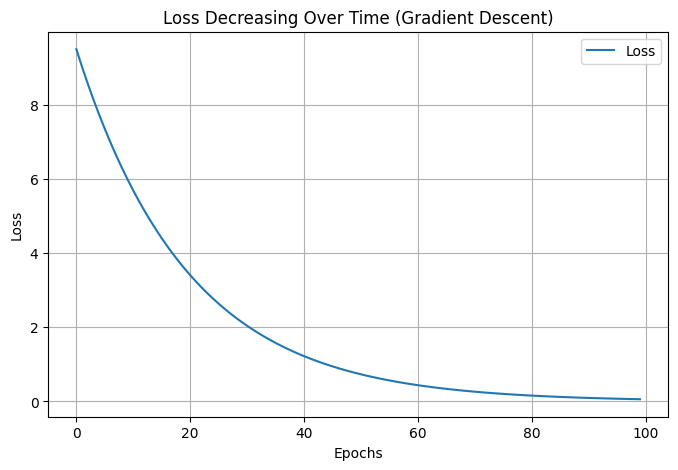

In [64]:
import numpy as np
import matplotlib.pyplot as plt

# Simulated loss values (normally comes from training loop)
losses = []

# Example: exponential decay to simulate training improvement
loss = 10
for epoch in range(100):
    loss = loss * 0.95   # loss decreases gradually
    losses.append(loss)

# Plot loss curve
plt.figure(figsize=(8, 5))
plt.plot(losses, label="Loss")

plt.title("Loss Decreasing Over Time (Gradient Descent)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

#  Question # 7 Optimizer and its Types (Basic & Advance)
- A 2-layer neural network (input → hidden → output)
- Activation function: ReLU for hidden layer, linear output (for regression)
- MSE loss
- Optimizers: SGD, Mini Batch, Momentum, RMSProp, Adam, AdaGrad

# Optimizers and Their Formulas (with Variable Explanation)

| Optimizer          | Update Formula | Explanation |
|-------------------|----------------|-------------|
| **SGD** | $\displaystyle \theta_{t+1} = \theta_t - \eta \nabla_\theta J(\theta_t)$ | $\theta_t$: current parameters<br> $\theta_{t+1}$: updated parameters<br> $\eta$: learning rate<br> $\nabla_\theta J(\theta_t)$: gradient of loss w.r.t parameters |
| **Momentum** | $\displaystyle v_t = \beta v_{t-1} + (1-\beta) \nabla_\theta J(\theta_t) <br> \theta_{t+1} = \theta_t - \eta v_t$ | $v_t$: velocity update<br> $v_{t-1}$: previous velocity<br> $\beta$: momentum factor (0.9 typical)<br> $\eta$: learning rate<br> $\nabla_\theta J(\theta_t)$: gradient |
| **RMSProp** | $\displaystyle E[g^2]_t = \rho E[g^2]_{t-1} + (1-\rho) (\nabla_\theta J(\theta_t))^2 <br> \theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{E[g^2]_t + \epsilon}} \nabla_\theta J(\theta_t)$ | $E[g^2]_t$: running avg of squared gradients<br> $\rho$: decay rate (0.9 typical)<br> $\eta$: learning rate<br> $\epsilon$: small value to avoid div by zero<br> $\nabla_\theta J(\theta_t)$: gradient |
| **Adam** | $\displaystyle m_t = \beta_1 m_{t-1} + (1-\beta_1) \nabla_\theta J(\theta_t) <br> v_t = \beta_2 v_{t-1} + (1-\beta_2) (\nabla_\theta J(\theta_t))^2 <br> \hat{m}_t = \frac{m_t}{1-\beta_1^t}, \hat{v}_t = \frac{v_t}{1-\beta_2^t} <br> \theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{\hat{v}_t} + \epsilon} \hat{m}_t$ | $m_t$: first moment (mean)<br> $v_t$: second moment (variance)<br> $\beta_1, \beta_2$: decay rates (0.9,0.999)<br> $\hat{m}_t, \hat{v}_t$: bias-corrected moments<br> $\eta$: learning rate<br> $\epsilon$: small value to avoid div by zero |
| **Mini-Batch SGD** | $\displaystyle \theta_{t+1} = \theta_t - \eta \frac{1}{B} \sum_{i=1}^{B} \nabla_\theta J_i(\theta_t)$ | $B$: mini-batch size<br> $\nabla_\theta J_i(\theta_t)$: gradient for each sample in batch<br> $\eta$: learning rate<br> $\theta_t, \theta_{t+1}$: params before/after update |
| **AdaGrad** | $\displaystyle G_t = G_{t-1} + (\nabla_\theta J(\theta_t))^2 <br> \theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{G_t} + \epsilon} \nabla_\theta J(\theta_t)$ | $G_t$: sum of squares of past gradients<br> $\nabla_\theta J(\theta_t)$: gradient<br> $\eta$: learning rate<br> $\epsilon$: small value to avoid div by zero |


In [8]:
import numpy as np  # numerical computations
from sklearn.datasets import load_diabetes  # regression dataset
from sklearn.model_selection import train_test_split  # split dataset
from sklearn.preprocessing import StandardScaler  # feature scaling


#### Dataset Preparation

In [10]:
# Load diabetes dataset
data = load_diabetes() # built in dataset of sklearn
X = data.data  # features
y = data.target.reshape(-1, 1)  # column vector for regression

In [11]:
print(data.feature_names)

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


In [12]:
X.shape  # Returns the shape (dimensions) of input tensor X
         # Example: (1, num_features)
         # 1 → number of samples (rows)
         # num_features → number of input features (columns)

(442, 10)

In [13]:
y.shape  # Returns the shape of target tensor y
         # Example: (1,)
         # 1 → number of labels (one class label for one sample)

(442, 1)

In [14]:
# Standardize features for better convergence
# (helps neural network learn faster and more stably)

scaler = StandardScaler()
# Create StandardScaler object
# It will transform data so that mean = 0 and standard deviation = 1

X = scaler.fit_transform(X)
# fit_transform:
# fit → learns mean and standard deviation from X
# transform → applies scaling using learned values
# Result → X becomes standardized (better for training neural networks)

In [15]:
# Split into train/test sets (80%-20%)
# This helps evaluate model on unseen data

X_train, X_test, y_train, y_test = train_test_split(
    X, y,                      # Input features and labels
    test_size=0.2,            # 20% data for testing, 80% for training
    random_state=42           # Ensures same split every time (reproducibility)
)

#### Neural Network Forward & Backward Functions

In [16]:
# Activation functions
def relu(Z):
    return np.maximum(0, Z)  # ReLU: max(0, Z)

def relu_derivative(Z):
    return (Z > 0).astype(float)  # derivative of ReLU

In [17]:
# Forward pass for 2-layer NN
def forward(X, W1, b1, W2, b2):
    # Define forward function for a simple neural network
    # X → input data, W1/W2 → weights, b1/b2 → biases

    Z1 = np.dot(X, W1) + b1
    # Hidden layer linear transformation
    # Z1 = XW1 + b1 (weighted sum + bias)

    A1 = relu(Z1)
    # Apply ReLU activation function
    # Converts linear output into non-linear representation

    Z2 = np.dot(A1, W2) + b2
    # Output layer linear transformation
    # Takes activated hidden layer output and computes final scores

    y_pred = Z2
    # Final prediction (no activation used here)
    # Suitable for regression problems

    cache = (X, Z1, A1, Z2)
    # Store intermediate values for backpropagation
    # Helps in computing gradients during training

    return y_pred, cache
    # Return predicted output and cached values

In [18]:
# Compute MSE Loss
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

In [20]:
# Backward pass: compute gradients
def backward(y_true, y_pred, cache, W2):
    # Function to compute gradients using backpropagation
    # y_true → actual values, y_pred → predicted values
    # cache → stored values from forward pass
    # W2 → weights of second layer (used for backprop)

    X, Z1, A1, Z2 = cache
    # Unpack cached values from forward pass

    m = X.shape[0]
    # Number of training samples (used for averaging gradients)

    dZ2 = (2/m) * (y_pred - y_true)
    # Gradient of loss w.r.t output layer
    # Measures error between prediction and actual value

    dW2 = np.dot(A1.T, dZ2)
    # Gradient of loss w.r.t weights of output layer
    # A1.T → transpose of hidden layer output

    db2 = np.sum(dZ2, axis=0, keepdims=True)
    # Gradient of loss w.r.t bias of output layer
    # Summed over all samples

    dA1 = np.dot(dZ2, W2.T)
    # Backpropagation to hidden layer
    # Distributes error back through weights W2

    dZ1 = dA1 * relu_derivative(Z1)
    # Apply chain rule through ReLU activation
    # Only passes gradient where Z1 > 0

    dW1 = np.dot(X.T, dZ1)
    # Gradient of loss w.r.t weights of first layer

    db1 = np.sum(dZ1, axis=0, keepdims=True)
    # Gradient of loss w.r.t bias of first layer

    return dW1, db1, dW2, db2
    # Return all computed gradients for weight updates

## Optimizers for Neural Network

##### 1. SGD

In [3]:
def train_sgd(X, y, hidden_size=32, lr=0.01, epochs=200):
    """
    Train a 2-layer neural network using Stochastic Gradient Descent (SGD)
    X: input features, shape (n_samples, n_features)
    y: target values, shape (n_samples, 1)
    hidden_size: number of neurons in hidden layer
    lr: learning rate
    epochs: number of iterations over the whole dataset
    """

    input_size = X.shape[1]       # number of input features (columns in X)
    output_size = y.shape[1]      # number of output neurons (usually 1 for regression)

    # ------------------------
    # Initialize weights randomly
    # ------------------------
    W1 = np.random.randn(input_size, hidden_size) * 0.01  # weights for input -> hidden
    b1 = np.zeros((1, hidden_size))                        # bias for hidden layer
    W2 = np.random.randn(hidden_size, output_size) * 0.01 # weights for hidden -> output
    b2 = np.zeros((1, output_size))                        # bias for output layer

    losses = []  # list to store loss at each epoch for plotting

    # ------------------------
    # Training loop over epochs
    # ------------------------
    for epoch in range(epochs):
        # Forward pass: compute predictions and cache intermediate values
        y_pred, cache = forward(X, W1, b1, W2, b2)  # cache needed for backprop

        # Compute Mean Squared Error loss
        loss = mse(y, y_pred)

        # Store loss for this epoch to track training progress
        losses.append(loss)

        # Backward pass: compute gradients for all weights and biases
        dW1, db1, dW2, db2 = backward(y, y_pred, cache, W2)

        # ------------------------
        # Update weights using SGD rule
        # ------------------------
        W1 -= lr * dW1  # update hidden layer weights
        b1 -= lr * db1  # update hidden layer bias
        W2 -= lr * dW2  # update output layer weights
        b2 -= lr * db2  # update output layer bias

    # Return final trained weights, biases, and list of loss per epoch
    return W1, b1, W2, b2, losses

##### 2. Mini batch

In [22]:
def create_mini_batches(X, y, batch_size=32, shuffle=True):
    """
    Splits dataset into mini-batches
    """

    m = X.shape[0]  # number of samples

    if shuffle:
        # Shuffle data randomly
        permutation = np.random.permutation(m)
        X = X[permutation]
        y = y[permutation]

    mini_batches = []

    # Create mini-batches
    for i in range(0, m, batch_size):
        X_batch = X[i:i + batch_size]
        y_batch = y[i:i + batch_size]
        mini_batches.append((X_batch, y_batch))

    return mini_batches

In [23]:
def train_sgd_minibatch(X, y, hidden_size=32, lr=0.001, epochs=200, batch_size=32):
    # Function to train neural network using Mini-batch Stochastic Gradient Descent

    input_size = X.shape[1]
    # Number of input features

    output_size = y.shape[1]
    # Number of output neurons (for regression or multi-output case)

    # -----------------------------
    # Xavier Initialization
    # -----------------------------
    W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2/input_size)
    # Initialize weights of first layer (input → hidden)
    # Xavier initialization helps stable training

    b1 = np.zeros((1, hidden_size))
    # Initialize bias of first layer to zero

    W2 = np.random.randn(hidden_size, output_size) * np.sqrt(2/hidden_size)
    # Initialize weights of second layer (hidden → output)

    b2 = np.zeros((1, output_size))
    # Initialize bias of second layer

    losses = []
    # Store loss for each epoch

    for epoch in range(epochs):
        # Loop over full dataset multiple times (training epochs)

        mini_batches = create_mini_batches(X, y, batch_size=batch_size, shuffle=True)
        # Split data into mini-batches and shuffle for better learning

        epoch_loss = 0
        # Track total loss for this epoch

        for X_batch, y_batch in mini_batches:
            # Loop over each mini-batch

            y_pred, cache = forward(X_batch, W1, b1, W2, b2)
            # Forward pass → get predictions

            loss = mse(y_batch, y_pred)
            # Compute Mean Squared Error loss

            epoch_loss += loss
            # Accumulate batch loss into epoch loss

            dW1, db1, dW2, db2 = backward(y_batch, y_pred, cache, W2)
            # Backpropagation → compute gradients

            # -----------------------------
            # Optional: Gradient Clipping
            # -----------------------------
            dW1 = np.clip(dW1, -1, 1)
            # Prevent very large gradients (stability)

            db1 = np.clip(db1, -1, 1)
            # Clip bias gradients

            dW2 = np.clip(dW2, -1, 1)
            # Clip weight gradients (layer 2)

            db2 = np.clip(db2, -1, 1)
            # Clip bias gradients (layer 2)

            # -----------------------------
            # Update Weights (Gradient Descent)
            # -----------------------------
            W1 -= lr * dW1
            # Update hidden layer weights

            b1 -= lr * db1
            # Update hidden layer bias

            W2 -= lr * dW2
            # Update output layer weights

            b2 -= lr * db2
            # Update output layer bias

        epoch_loss /= len(mini_batches)
        # Compute average loss per epoch

        losses.append(epoch_loss)
        # Store epoch loss for visualization

    return W1, b1, W2, b2, losses
    # Return trained weights and loss history

##### 3. Momentum

In [4]:
def train_momentum(X, y, hidden_size=32, lr=0.01, beta=0.9, epochs=200):
    """
    Train 2-layer neural network using SGD with Momentum
    X: input features
    y: target values
    hidden_size: neurons in hidden layer
    lr: learning rate
    beta: momentum coefficient (0 < beta < 1)
    epochs: number of iterations
    """

    input_size = X.shape[1]      # number of input features
    output_size = y.shape[1]     # output dimension

    # -----------------------------
    # Initialize weights randomly
    # -----------------------------
    W1 = np.random.randn(input_size, hidden_size) * 0.01
    # Small random weights for input → hidden layer

    b1 = np.zeros((1, hidden_size))
    # Bias for hidden layer initialized to zero

    W2 = np.random.randn(hidden_size, output_size) * 0.01
    # Small random weights for hidden → output layer

    b2 = np.zeros((1, output_size))
    # Bias for output layer initialized to zero

    # -----------------------------
    # Initialize momentum (velocity terms)
    # -----------------------------
    vW1 = np.zeros_like(W1)
    # Velocity for W1 (tracks past gradients)

    vb1 = np.zeros_like(b1)
    # Velocity for b1

    vW2 = np.zeros_like(W2)
    # Velocity for W2

    vb2 = np.zeros_like(b2)
    # Velocity for b2

    losses = []
    # Store loss for each epoch

    # -----------------------------
    # Training loop
    # -----------------------------
    for epoch in range(epochs):

        # Forward pass
        y_pred, cache = forward(X, W1, b1, W2, b2)
        # Compute predictions using current weights

        # Compute loss
        loss = mse(y, y_pred)
        # Measure error between predicted and true values

        losses.append(loss)
        # Save loss for visualization / analysis

        # Backward pass: compute gradients
        dW1, db1, dW2, db2 = backward(y, y_pred, cache, W2)
        # Compute gradients using backpropagation

        # -----------------------------
        # Update velocities with momentum
        # -----------------------------
        vW1 = beta * vW1 + (1 - beta) * dW1
        # Combine past velocity with current gradient (W1)

        vb1 = beta * vb1 + (1 - beta) * db1
        # Momentum update for bias b1

        vW2 = beta * vW2 + (1 - beta) * dW2
        # Momentum update for W2

        vb2 = beta * vb2 + (1 - beta) * db2
        # Momentum update for b2

        # -----------------------------
        # Update weights using velocities
        # -----------------------------
        W1 -= lr * vW1
        # Update W1 using momentum

        b1 -= lr * vb1
        # Update b1 using momentum

        W2 -= lr * vW2
        # Update W2 using momentum

        b2 -= lr * vb2
        # Update b2 using momentum

    # Return trained weights, biases, and loss history
    return W1, b1, W2, b2, losses

##### 4. RMSProp
Instead of using same learning rate for all weights:

- RMSProp uses adaptive learning rate per parameter

- Large gradients → smaller step
- Small gradients → larger step

In [25]:
def train_rmsprop(X, y, hidden_size=32, lr=0.001, beta=0.9, epsilon=1e-8, epochs=200):
    """
    Train 2-layer neural network using RMSProp optimizer
    lr: learning rate
    beta: decay rate for moving average of squared gradients
    epsilon: small constant to avoid division by zero
    """

    input_size = X.shape[1]
    output_size = y.shape[1]

    # -----------------------------
    # Initialize weights
    # -----------------------------
    W1 = np.random.randn(input_size, hidden_size) * 0.01
    # Input → Hidden weights initialized small random values

    b1 = np.zeros((1, hidden_size))
    # Hidden layer bias initialized to zero

    W2 = np.random.randn(hidden_size, output_size) * 0.01
    # Hidden → Output weights

    b2 = np.zeros((1, output_size))
    # Output bias

    # -----------------------------
    # Initialize squared gradient accumulators
    # -----------------------------
    sW1 = np.zeros_like(W1)
    # Running average of squared gradients for W1

    sb1 = np.zeros_like(b1)
    # Running average for b1

    sW2 = np.zeros_like(W2)
    # Running average for W2

    sb2 = np.zeros_like(b2)
    # Running average for b2

    losses = []
    # Store loss per epoch for analysis

    # -----------------------------
    # Training loop
    # -----------------------------
    for epoch in range(epochs):

        # Forward pass
        y_pred, cache = forward(X, W1, b1, W2, b2)
        # Compute model predictions

        # Compute loss
        loss = mse(y, y_pred)
        # Mean Squared Error calculation

        losses.append(loss)
        # Store loss for plotting/analysis

        # Backward pass
        dW1, db1, dW2, db2 = backward(y, y_pred, cache, W2)
        # Compute gradients using backpropagation

        # -----------------------------
        # RMSProp: Update squared gradients
        # -----------------------------
        sW1 = beta * sW1 + (1 - beta) * (dW1 ** 2)
        # Smooth average of squared gradients (W1)

        sb1 = beta * sb1 + (1 - beta) * (db1 ** 2)
        # Bias hidden layer

        sW2 = beta * sW2 + (1 - beta) * (dW2 ** 2)
        # Output weights

        sb2 = beta * sb2 + (1 - beta) * (db2 ** 2)
        # Output bias

        # -----------------------------
        # Update weights using RMSProp rule
        # -----------------------------
        W1 -= lr * dW1 / (np.sqrt(sW1) + epsilon)
        # Adaptive learning rate for W1

        b1 -= lr * db1 / (np.sqrt(sb1) + epsilon)
        # Adaptive update for bias b1

        W2 -= lr * dW2 / (np.sqrt(sW2) + epsilon)
        # Adaptive update for W2

        b2 -= lr * db2 / (np.sqrt(sb2) + epsilon)
        # Adaptive update for b2

    return W1, b1, W2, b2, losses

##### 5. Adam
Adam = Momentum + RMSProp
| Part              | Meaning                     |
| ----------------- | --------------------------- |
| m (first moment)  | direction (like momentum)   |
| v (second moment) | step scaling (like RMSProp) |
| bias correction   | fixes early training bias   |


In [5]:
def train_adam(X, y, hidden_size=32, lr=0.001, beta1=0.9, beta2=0.999, epsilon=1e-8, epochs=200):
    """
    Train 2-layer neural network using Adam optimizer
    Combines momentum (first moment) and RMSProp (second moment)
    """

    input_size = X.shape[1]
    output_size = y.shape[1]

    # -----------------------------
    # Initialize weights
    # -----------------------------
    W1 = np.random.randn(input_size, hidden_size) * 0.01
    # Input → Hidden weights

    b1 = np.zeros((1, hidden_size))
    # Hidden bias

    W2 = np.random.randn(hidden_size, output_size) * 0.01
    # Hidden → Output weights

    b2 = np.zeros((1, output_size))
    # Output bias

    # -----------------------------
    # Initialize first moment (m) and second moment (v)
    # -----------------------------
    mW1 = np.zeros_like(W1)
    vW1 = np.zeros_like(W1)

    mb1 = np.zeros_like(b1)
    vb1 = np.zeros_like(b1)

    mW2 = np.zeros_like(W2)
    vW2 = np.zeros_like(W2)

    mb2 = np.zeros_like(b2)
    vb2 = np.zeros_like(b2)

    losses = []
    # Store loss per epoch

    # -----------------------------
    # Training loop
    # -----------------------------
    for t in range(1, epochs + 1):

        # Forward pass
        y_pred, cache = forward(X, W1, b1, W2, b2)
        # Model prediction

        # Compute loss
        loss = mse(y, y_pred)
        # Error calculation

        losses.append(loss)
        # Save loss

        # Backward pass
        dW1, db1, dW2, db2 = backward(y, y_pred, cache, W2)
        # Gradient computation

        # -----------------------------
        # First moment update (Momentum)
        # -----------------------------
        mW1 = beta1 * mW1 + (1 - beta1) * dW1
        mb1 = beta1 * mb1 + (1 - beta1) * db1
        mW2 = beta1 * mW2 + (1 - beta1) * dW2
        mb2 = beta1 * mb2 + (1 - beta1) * db2

        # -----------------------------
        # Second moment update (RMSProp)
        # -----------------------------
        vW1 = beta2 * vW1 + (1 - beta2) * (dW1 ** 2)
        vb1 = beta2 * vb1 + (1 - beta2) * (db1 ** 2)
        vW2 = beta2 * vW2 + (1 - beta2) * (dW2 ** 2)
        vb2 = beta2 * vb2 + (1 - beta2) * (db2 ** 2)

        # -----------------------------
        # Bias correction (important in Adam)
        # -----------------------------
        mW1_hat = mW1 / (1 - beta1 ** t)
        mb1_hat = mb1 / (1 - beta1 ** t)
        mW2_hat = mW2 / (1 - beta1 ** t)
        mb2_hat = mb2 / (1 - beta1 ** t)

        vW1_hat = vW1 / (1 - beta2 ** t)
        vb1_hat = vb1 / (1 - beta2 ** t)
        vW2_hat = vW2 / (1 - beta2 ** t)
        vb2_hat = vb2 / (1 - beta2 ** t)

        # -----------------------------
        # Parameter update (Adam rule)
        # -----------------------------
        W1 -= lr * mW1_hat / (np.sqrt(vW1_hat) + epsilon)
        # Update hidden weights

        b1 -= lr * mb1_hat / (np.sqrt(vb1_hat) + epsilon)
        # Update hidden bias

        W2 -= lr * mW2_hat / (np.sqrt(vW2_hat) + epsilon)
        # Update output weights

        b2 -= lr * mb2_hat / (np.sqrt(vb2_hat) + epsilon)
        # Update output bias

    return W1, b1, W2, b2, losses

##### 6. AdaGrad
- Each parameter gets its own learning rate
- Frequently updated weights → smaller steps
- Rarely updated weights → larger steps

In [6]:
def train_adagrad(X, y, hidden_size=32, lr=0.01, epsilon=1e-8, epochs=200):
    """
    Train a 2-layer neural network using AdaGrad optimizer
    X: input features
    y: target values
    hidden_size: neurons in hidden layer
    lr: base learning rate
    epsilon: small value to avoid division by zero
    epochs: number of training iterations
    """

    input_size = X.shape[1]       # number of input features
    output_size = y.shape[1]      # number of output neurons

    # -----------------------------
    # Xavier Initialization
    # -----------------------------
    W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2 / input_size)
    # Input → Hidden weights initialized for stable gradients

    b1 = np.zeros((1, hidden_size))
    # Hidden layer bias initialized to zero

    W2 = np.random.randn(hidden_size, output_size) * np.sqrt(2 / hidden_size)
    # Hidden → Output weights

    b2 = np.zeros((1, output_size))
    # Output bias

    # -----------------------------
    # AdaGrad: Accumulated squared gradients
    # -----------------------------
    G_W1 = np.zeros_like(W1)
    # Stores sum of squared gradients for W1

    G_b1 = np.zeros_like(b1)
    # Stores sum of squared gradients for b1

    G_W2 = np.zeros_like(W2)
    # Stores sum of squared gradients for W2

    G_b2 = np.zeros_like(b2)
    # Stores sum of squared gradients for b2

    losses = []
    # Store loss values for each epoch

    # -----------------------------
    # Training loop
    # -----------------------------
    for epoch in range(epochs):

        # Forward pass
        y_pred, cache = forward(X, W1, b1, W2, b2)
        # Compute predictions using current weights

        # Compute loss
        loss = mse(y, y_pred)
        # Measure error between predicted and actual values

        losses.append(loss)
        # Save loss for analysis

        # Backward pass
        dW1, db1, dW2, db2 = backward(y, y_pred, cache, W2)
        # Compute gradients using backpropagation

        # -----------------------------
        # Accumulate squared gradients
        # -----------------------------
        G_W1 += dW1 ** 2
        # Sum of squared gradients for W1

        G_b1 += db1 ** 2
        # Sum of squared gradients for b1

        G_W2 += dW2 ** 2
        # Sum of squared gradients for W2

        G_b2 += db2 ** 2
        # Sum of squared gradients for b2

        # -----------------------------
        # AdaGrad parameter update
        # -----------------------------
        W1 -= (lr / (np.sqrt(G_W1) + epsilon)) * dW1
        # Adaptive learning rate for W1

        b1 -= (lr / (np.sqrt(G_b1) + epsilon)) * db1
        # Adaptive learning rate for b1

        W2 -= (lr / (np.sqrt(G_W2) + epsilon)) * dW2
        # Adaptive learning rate for W2

        b2 -= (lr / (np.sqrt(G_b2) + epsilon)) * db2
        # Adaptive learning rate for b2

    # Return trained parameters and loss history
    return W1, b1, W2, b2, losses

### Train All Optimizers

In [26]:
epochs = 200    # total number of training epochs
hidden_size = 32  # number of neurons in hidden layer
lr_sgd = 0.01    # learning rate for SGD and Momentum
lr_adv = 0.001   # learning rate for RMSProp and Adam

# -----------------------------
# Train with SGD
# -----------------------------
W1_sgd, b1_sgd, W2_sgd, b2_sgd, losses_sgd = train_sgd(X_train, y_train,
                                                       hidden_size=hidden_size,
                                                       lr=lr_sgd,
                                                       epochs=epochs)
# -----------------------------
# Train with Mini-Batch SGD
# -----------------------------
W1_sgd_mini, b1_sgd_mini, W2_sgd_mini, b2_sgd_mini, losses_sgd_mini = train_sgd_minibatch(
    X_train,               # input features
    y_train,               # target labels
    hidden_size=hidden_size,  # neurons in hidden layer
    lr=lr_sgd,             # learning rate
    epochs=epochs,         # total number of epochs
    batch_size=32          # mini-batch size
)
# -----------------------------
# Train with Momentum
# -----------------------------
W1_mom, b1_mom, W2_mom, b2_mom, losses_mom = train_momentum(X_train, y_train,
                                                           hidden_size=hidden_size,
                                                           lr=lr_sgd,
                                                           beta=0.9,
                                                           epochs=epochs)

# -----------------------------
# Train with RMSProp
# -----------------------------
W1_rms, b1_rms, W2_rms, b2_rms, losses_rms = train_rmsprop(X_train, y_train,
                                                          hidden_size=hidden_size,
                                                          lr=lr_adv,
                                                          beta=0.9,
                                                          epsilon=1e-8,
                                                          epochs=epochs)

# -----------------------------
# Train with Adam
# -----------------------------
W1_adam, b1_adam, W2_adam, b2_adam, losses_adam = train_adam(X_train, y_train,
                                                            hidden_size=hidden_size,
                                                            lr=lr_adv,
                                                            beta1=0.9,
                                                            beta2=0.999,
                                                            epsilon=1e-8,
                                                            epochs=epochs)
# -----------------------------
# Train with AdaGrad
# -----------------------------
W1_adagrad, b1_adagrad, W2_adagrad, b2_adagrad, losses_adagrad = train_adagrad(
    X_train, y_train,
    hidden_size=hidden_size,
    lr=lr_sgd,      # learning rate
    epochs=epochs   # number of training iterations
)

/tmp/ipykernel_2595/2572407946.py:3: RuntimeWarning: overflow encountered in square
  return np.mean((y_true - y_pred) ** 2)
/tmp/ipykernel_2595/3888824274.py:30: RuntimeWarning: invalid value encountered in multiply
  dZ1 = dA1 * relu_derivative(Z1)


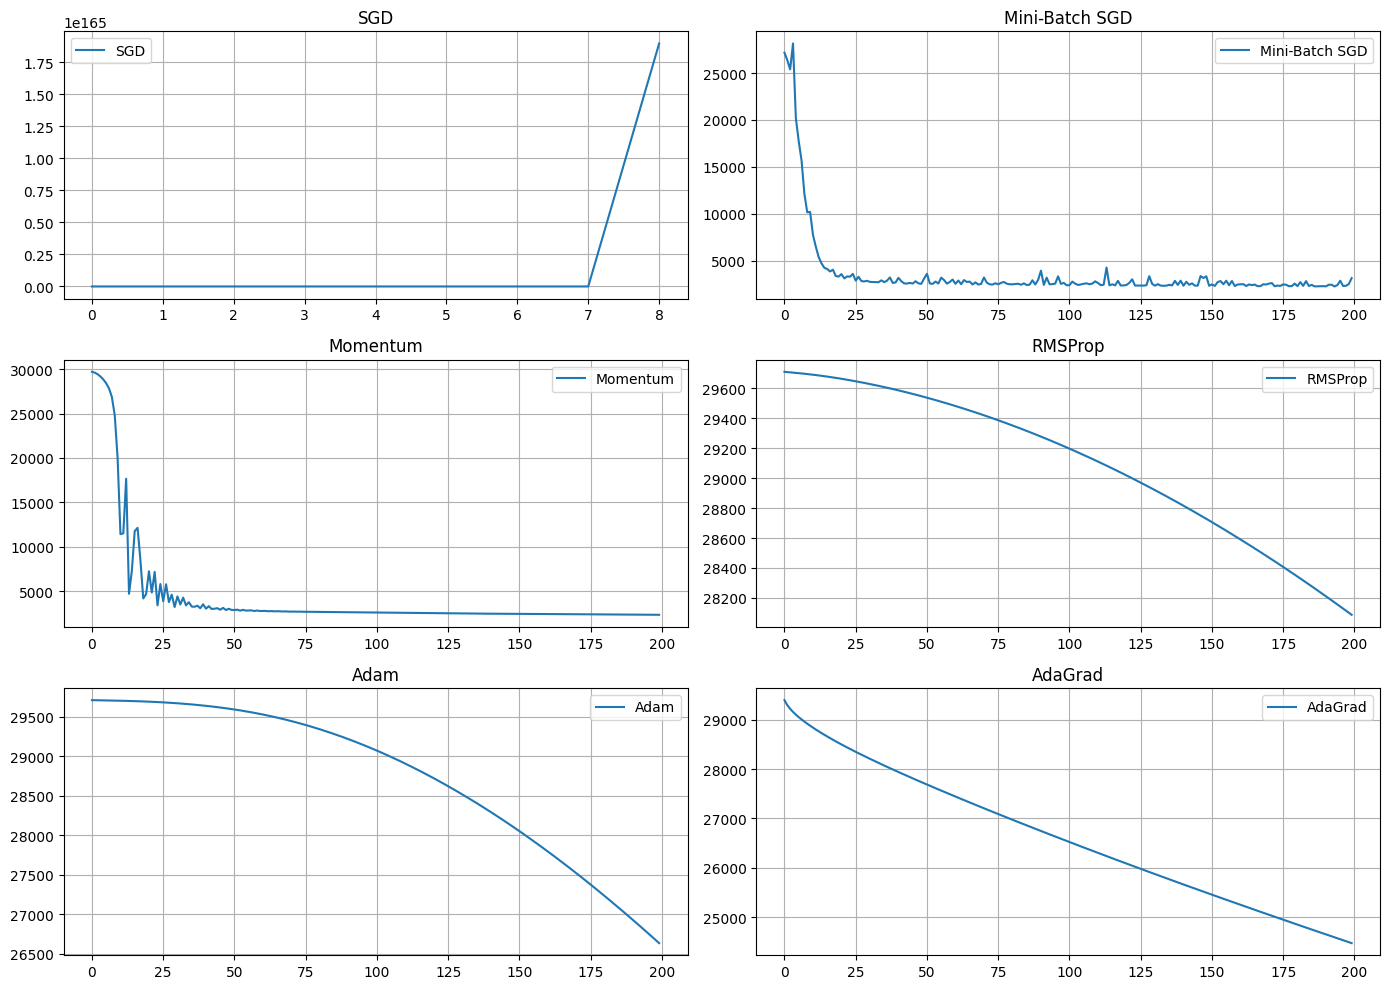

In [27]:
import matplotlib.pyplot as plt
# Import matplotlib library for plotting graphs

plt.figure(figsize=(14, 10))
# Create a figure (canvas) with width=14 and height=10 inches

# 3 rows, 2 columns → positions 1 to 6
# This means we are creating 6 subplots in a grid layout

plt.subplot(3, 2, 1)
# First subplot (row 1, column 1)

plt.plot(losses_sgd, label='SGD')
# Plot loss curve for SGD optimizer

plt.title('SGD')
# Set title of first graph

plt.grid(True)
# Show grid lines for better readability

plt.legend()
# Display label (SGD)

# -----------------------------

plt.subplot(3, 2, 2)
# Second subplot (row 1, column 2)

plt.plot(losses_sgd_mini, label='Mini-Batch SGD')
# Plot loss curve for Mini-Batch SGD

plt.title('Mini-Batch SGD')
# Set title

plt.grid(True)
# Show grid

plt.legend()
# Show legend

# -----------------------------

plt.subplot(3, 2, 3)
# Third subplot (row 2, column 1)

plt.plot(losses_mom, label='Momentum')
# Plot loss curve for Momentum optimizer

plt.title('Momentum')
# Set title

plt.grid(True)
# Enable grid

plt.legend()
# Show legend

# -----------------------------

plt.subplot(3, 2, 4)
# Fourth subplot (row 2, column 2)

plt.plot(losses_rms, label='RMSProp')
# Plot RMSProp loss curve

plt.title('RMSProp')
# Set title

plt.grid(True)
# Show grid

plt.legend()
# Show legend

# -----------------------------

plt.subplot(3, 2, 5)
# Fifth subplot (row 3, column 1)

plt.plot(losses_adam, label='Adam')
# Plot Adam optimizer loss curve

plt.title('Adam')
# Set title

plt.grid(True)
# Show grid

plt.legend()
# Show legend

# -----------------------------

plt.subplot(3, 2, 6)
# Sixth subplot (row 3, column 2)

plt.plot(losses_adagrad, label='AdaGrad')
# Plot AdaGrad loss curve

plt.title('AdaGrad')
# Set title

plt.grid(True)
# Show grid

plt.legend()
# Show legend

# -----------------------------

plt.tight_layout()
# Automatically adjust spacing between subplots to avoid overlap

plt.show()
# Display all plots on screen

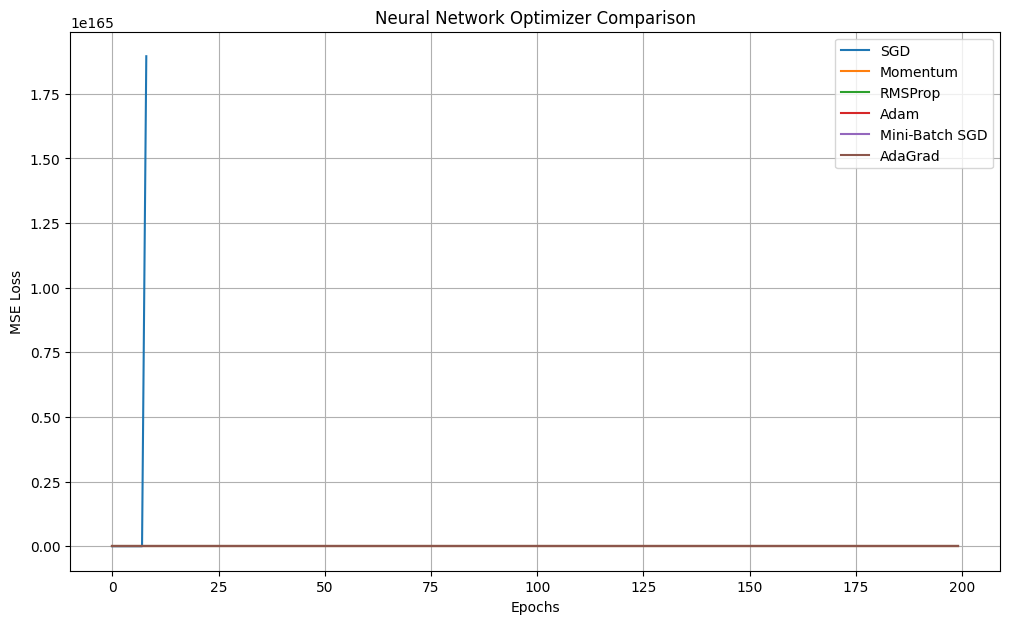

In [28]:
import matplotlib.pyplot as plt
# Import matplotlib library for plotting graphs

plt.figure(figsize=(12, 7))
# Create a figure with width=12 and height=7 inches for better visibility

# -----------------------------
# Plot loss for each optimizer
# -----------------------------
plt.plot(losses_sgd, label='SGD')
# Plot loss curve for standard SGD optimizer

plt.plot(losses_mom, label='Momentum')
# Plot loss curve for Momentum optimizer

plt.plot(losses_rms, label='RMSProp')
# Plot loss curve for RMSProp optimizer

plt.plot(losses_adam, label='Adam')
# Plot loss curve for Adam optimizer

plt.plot(losses_sgd_mini, label='Mini-Batch SGD')
# Plot loss curve for Mini-Batch SGD optimizer

plt.plot(losses_adagrad, label='AdaGrad')
# Plot loss curve for AdaGrad optimizer

# -----------------------------
# Labels and title
# -----------------------------
plt.xlabel('Epochs')
# X-axis label → number of training iterations

plt.ylabel('MSE Loss')
# Y-axis label → error value (Mean Squared Error)

plt.title('Neural Network Optimizer Comparison')
# Title of the graph

# -----------------------------
# Show legend and grid
# -----------------------------
plt.legend()
# Display labels for each optimizer curve

plt.grid(True)
# Enable grid for better visualization

# -----------------------------
# Display plot
# -----------------------------
plt.show()
# Render and display the final graph

# Question # 8: Demnostration of Overfitting and Underfitting

In [1]:
from google.colab import files
files.upload()  # upload kaggle.json


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"hiranawaz2415","key":"7ade3180923fb5ac9db4b376a34cc842"}'}

In [2]:
!mkdir -p ~/.kaggle
# Create a hidden folder named ".kaggle" in the home directory
# -p ensures no error if folder already exists

!cp kaggle.json ~/.kaggle/
# Copy the kaggle.json file (API key file) into the ~/.kaggle directory
# This is required for Kaggle authentication

!chmod 600 ~/.kaggle/kaggle.json
# Set file permissions so only the owner can read/write the file
# This is required for security (Kaggle rejects insecure permissions)

In [3]:
!wget https://gist.githubusercontent.com/tgcsantos/f02a288c38646ad167997c213ae20412/raw/uci_pima_indians_diabetes.csv -O pima_diabetes.csv
# Download a dataset from the given URL using wget (web get tool)
# This fetches the Pima Indians Diabetes dataset from an online source

# -O pima_diabetes.csv
# Save the downloaded file with the name "pima_diabetes.csv"
# Instead of a long URL filename, we give it a clean local file name

--2026-04-22 14:23:48--  https://gist.githubusercontent.com/tgcsantos/f02a288c38646ad167997c213ae20412/raw/uci_pima_indians_diabetes.csv
Resolving gist.githubusercontent.com (gist.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to gist.githubusercontent.com (gist.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 23105 (23K) [text/plain]
Saving to: ‘pima_diabetes.csv’

pima_diabetes.csv   100%[===================>]  22.56K  --.-KB/s    in 0s      

2026-04-22 14:23:48 (71.8 MB/s) - ‘pima_diabetes.csv’ saved [23105/23105]



## Dataset Description: Pima Indians Diabetes Dataset
- **Source:** UCI Machine Learning Repository
- **Number of Instances:** 768
- **Number of Attributes (Features):** 8 + 1 target variable
- **Target Variable:** Outcome — indicates whether the patient has diabetes (1) or not (0)

### Feature Details

- **Pregnancies** – Number of times pregnant
- **Glucose** – Plasma glucose concentration (mg/dL)
- **BloodPressure** – Diastolic blood pressure (mm Hg)
- **SkinThickness** – Triceps skin fold thickness (mm)
- **Insulin** – 2-Hour serum insulin (mu U/ml)
- **BMI** – Body mass index (kg/m²)
- **DiabetesPedigreeFunction** – Genetic influence score
- **Age** – Age in years

In [4]:
# -----------------------------
# 1. IMPORT LIBRARIES
# -----------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
# -----------------------------
# 2. LOAD DATA
# -----------------------------
data = pd.read_csv("pima_diabetes.csv")  # Load CSV file
print("Shape of dataset:", data.shape)
print(data.head())                        # Preview first 5 rows

Shape of dataset: (768, 9)
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [8]:
# -----------------------------
# 3. SPLIT FEATURES AND LABELS
# -----------------------------
X = data.drop("Outcome", axis=1).values  # Features
y = data["Outcome"].values               # Labels (0 or 1)

In [24]:
# -----------------------------
# 4. NORMALIZE FEATURES
# -----------------------------
X = (X - X.mean(axis=0)) / X.std(axis=0) # Standardization: zero mean, unit variance

In [25]:
# -----------------------------
# 5. ONE-HOT ENCODING FOR LABELS
# -----------------------------
# One-hot encoding converts class labels (0,1,2,...) into vector form
# Example: class 1 → [0,1,0] if num_classes = 3

def one_hot(y, num_classes=2):
    # Create a matrix of zeros with shape (number of samples, number of classes)
    out = np.zeros((y.size, num_classes))

    # np.arange(y.size) gives row indices (0 to n-1)
    # y gives column index (class label)
    # This places 1 at correct class position for each sample
    out[np.arange(y.size), y] = 1

    # Return one-hot encoded matrix
    return out

In [26]:
Y = one_hot(y)

In [27]:
# -----------------------------
# 6. TRAIN / TEST SPLIT
# -----------------------------
# This step divides dataset into training and testing sets

split = int(0.5 * len(X))
# Calculate split index
# 50% of data is used for training and 50% for testing
# (Note: comment says 60%, but code uses 50%)

X_train, X_test = X[:split], X[split:]
# First half of data → training features
# Second half of data → testing features

Y_train, Y_test = Y[:split], Y[split:]
# First half of labels → training labels
# Second half of labels → testing labels

In [28]:
# -----------------------------
# 7. NETWORK PARAMETERS
# -----------------------------
input_size = X_train.shape[1]
h1, h2 = 128, 64
output_size = 2
lr = 0.05
epochs = 600
dropout_rate = 0.3   # only used in Step 2


In [29]:
# -----------------------------
# 7. WEIGHT INITIALIZATION
# -----------------------------
# This function initializes weights and biases for a 3-layer neural network

def init_weights(input_size, h1, h2, output_size):

    # -----------------------------
    # Input → Hidden Layer 1 weights
    # -----------------------------
    W1 = np.random.randn(input_size, h1) * np.sqrt(2. / input_size)
    # Random initialization using He initialization
    # Helps avoid vanishing/exploding gradients

    b1 = np.zeros(h1)
    # Bias for first hidden layer initialized to zero

    # -----------------------------
    # Hidden Layer 1 → Hidden Layer 2
    # -----------------------------
    W2 = np.random.randn(h1, h2) * np.sqrt(2. / h1)
    # Weights between hidden layers using He initialization

    b2 = np.zeros(h2)
    # Bias for second hidden layer initialized to zero

    # -----------------------------
    # Hidden Layer 2 → Output Layer
    # -----------------------------
    W3 = np.random.randn(h2, output_size) * np.sqrt(2. / h2)
    # Output layer weights initialization

    b3 = np.zeros(output_size)
    # Output layer bias initialized to zero

    # -----------------------------
    # Return all initialized parameters
    # -----------------------------
    return W1, b1, W2, b2, W3, b3

In [30]:
# -----------------------------
# 9. ACTIVATION FUNCTIONS
# -----------------------------
def relu(x): return np.maximum(0, x)
def relu_derivative(x): return (x > 0).astype(float)
def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / exp_x.sum(axis=1, keepdims=True)
def cross_entropy(y_true, y_pred):
    return -np.mean(np.sum(y_true * np.log(y_pred + 1e-8), axis=1))


In [31]:
# -----------------------------
# 9. TRAIN FUNCTION
# -----------------------------
def train_mlp(dropout=False, early_stop=False):
    W1, b1, W2, b2, W3, b3 = init_weights(input_size, h1, h2, output_size)
    train_losses, test_losses = [], []
    best_test_loss = np.inf
    patience, wait = 20, 0   # Early stopping patience

    for epoch in range(epochs):
        # --------- FORWARD PASS ----------
        Z1 = X_train.dot(W1) + b1
        A1 = relu(Z1)

        # Apply dropout if enabled
        if dropout:
            mask = (np.random.rand(*A1.shape) > dropout_rate) / (1 - dropout_rate)
            A1 *= mask
        else:
            mask = np.ones_like(A1)

        Z2 = A1.dot(W2) + b2
        A2 = relu(Z2)
        Z3 = A2.dot(W3) + b3
        Y_hat = softmax(Z3)

        # --------- LOSS ----------
        loss = cross_entropy(Y_train, Y_hat)
        train_losses.append(loss)

        # --------- BACKPROP ----------
        dZ3 = Y_hat - Y_train
        dW3 = A2.T.dot(dZ3) / X_train.shape[0]
        db3 = dZ3.mean(axis=0)
        dA2 = dZ3.dot(W3.T)
        dZ2 = dA2 * relu_derivative(Z2)
        dW2 = A1.T.dot(dZ2) / X_train.shape[0]
        db2 = dZ2.mean(axis=0)
        dA1 = dZ2.dot(W2.T) * mask
        dZ1 = dA1 * relu_derivative(Z1)
        dW1 = X_train.T.dot(dZ1) / X_train.shape[0]
        db1 = dZ1.mean(axis=0)

        # --------- UPDATE WEIGHTS ----------
        W3 -= lr * dW3
        b3 -= lr * db3
        W2 -= lr * dW2
        b2 -= lr * db2
        W1 -= lr * dW1
        b1 -= lr * db1

        # --------- TEST LOSS ----------
        Z1_test = X_test.dot(W1) + b1
        A1_test = relu(Z1_test)
        Z2_test = A1_test.dot(W2) + b2
        A2_test = relu(Z2_test)
        Z3_test = A2_test.dot(W3) + b3
        Y_hat_test = softmax(Z3_test)
        test_loss = cross_entropy(Y_test, Y_hat_test)
        test_losses.append(test_loss)

        # --------- EARLY STOPPING ----------
        if early_stop:
            if test_loss < best_test_loss:
                best_test_loss = test_loss
                wait = 0
            else:
                wait += 1
            if wait >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

        # --------- PRINT PROGRESS ----------
        if epoch % 20 == 0:
            print(f"Epoch {epoch}, Train Loss: {loss:.4f}, Test Loss: {test_loss:.4f}")

    return train_losses, test_losses

In [32]:
# -----------------------------
# 10. STEP 1: TRAIN WITHOUT DROPOUT (Overfitting demo)
# -----------------------------
train1, test1 = train_mlp(dropout=False, early_stop=False)

Epoch 0, Train Loss: 1.2804, Test Loss: 0.9255
Epoch 20, Train Loss: 0.4756, Test Loss: 0.4623
Epoch 40, Train Loss: 0.4471, Test Loss: 0.4532
Epoch 60, Train Loss: 0.4275, Test Loss: 0.4506
Epoch 80, Train Loss: 0.4122, Test Loss: 0.4498
Epoch 100, Train Loss: 0.3995, Test Loss: 0.4511
Epoch 120, Train Loss: 0.3880, Test Loss: 0.4536
Epoch 140, Train Loss: 0.3771, Test Loss: 0.4577
Epoch 160, Train Loss: 0.3667, Test Loss: 0.4621
Epoch 180, Train Loss: 0.3569, Test Loss: 0.4671
Epoch 200, Train Loss: 0.3477, Test Loss: 0.4720
Epoch 220, Train Loss: 0.3389, Test Loss: 0.4769
Epoch 240, Train Loss: 0.3301, Test Loss: 0.4818
Epoch 260, Train Loss: 0.3216, Test Loss: 0.4871
Epoch 280, Train Loss: 0.3132, Test Loss: 0.4921
Epoch 300, Train Loss: 0.3052, Test Loss: 0.4968
Epoch 320, Train Loss: 0.2974, Test Loss: 0.5018
Epoch 340, Train Loss: 0.2898, Test Loss: 0.5064
Epoch 360, Train Loss: 0.2822, Test Loss: 0.5108
Epoch 380, Train Loss: 0.2749, Test Loss: 0.5152
Epoch 400, Train Loss: 0.2

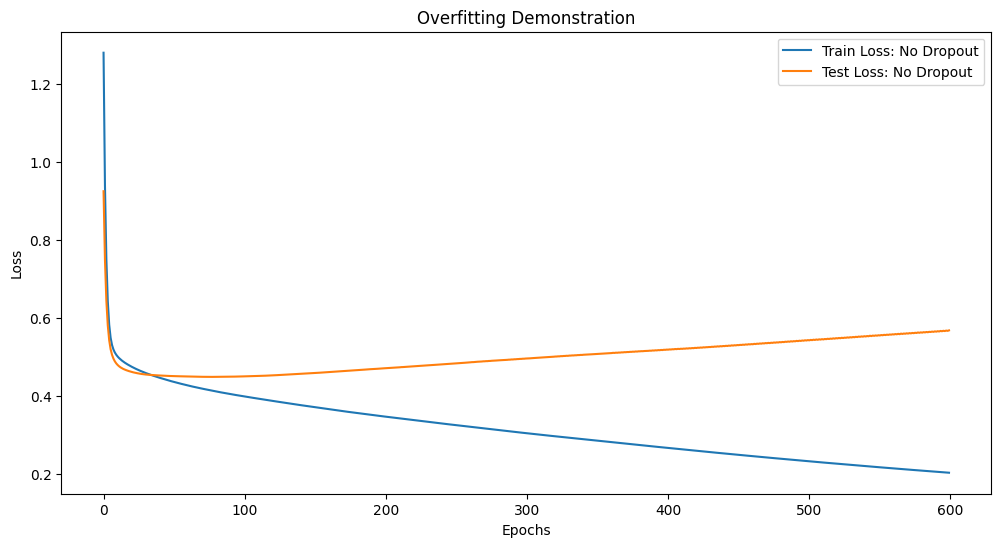

In [33]:
plt.figure(figsize=(12,6))
plt.plot(train1, label="Train Loss: No Dropout")
plt.plot(test1, label="Test Loss: No Dropout")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Overfitting Demonstration")
plt.legend()
plt.show()

In [37]:
# -----------------------------
# UNDERFITTING SETUP
# -----------------------------

h1, h2 = 4, 2          # very small network (low capacity)
epochs = 30            # very few training iterations
lr = 0.001             # very slow learning rate

# IMPORTANT: call function with these parameters properly
train_underfit, test_underfit = train_mlp(dropout=False, early_stop=False)

Epoch 0, Train Loss: 0.7163, Test Loss: 0.7117
Epoch 20, Train Loss: 0.7157, Test Loss: 0.7110


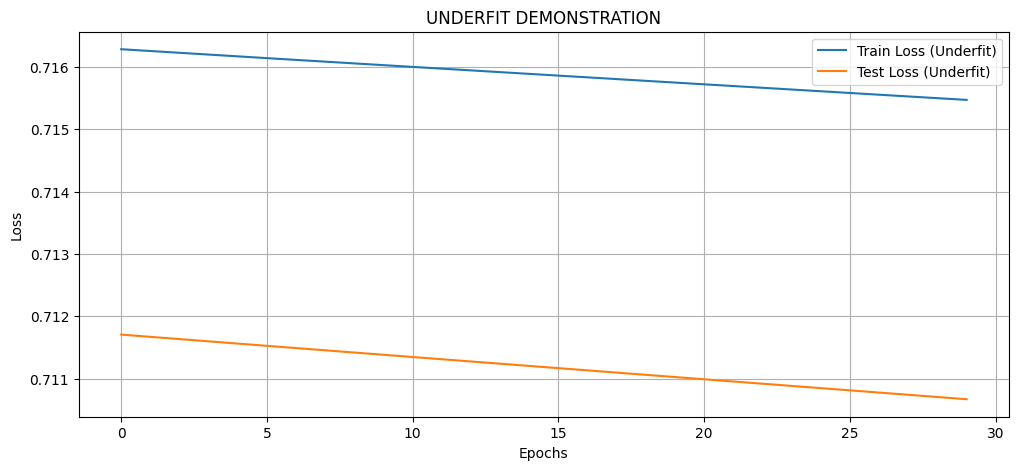

In [38]:
plt.figure(figsize=(12,5))
plt.plot(train_underfit, label="Train Loss (Underfit)")
plt.plot(test_underfit, label="Test Loss (Underfit)")
plt.title("UNDERFIT DEMONSTRATION")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [39]:
# -----------------------------
# Goodfitting SETUP
# -----------------------------
h1, h2 = 128, 64
epochs = 600

train_overfit, test_overfit = train_mlp(dropout=False, early_stop=False)

Epoch 0, Train Loss: 0.7562, Test Loss: 0.8014
Epoch 20, Train Loss: 0.6846, Test Loss: 0.7110
Epoch 40, Train Loss: 0.6450, Test Loss: 0.6598
Epoch 60, Train Loss: 0.6184, Test Loss: 0.6259
Epoch 80, Train Loss: 0.5984, Test Loss: 0.6009
Epoch 100, Train Loss: 0.5828, Test Loss: 0.5816
Epoch 120, Train Loss: 0.5703, Test Loss: 0.5662
Epoch 140, Train Loss: 0.5602, Test Loss: 0.5537
Epoch 160, Train Loss: 0.5518, Test Loss: 0.5433
Epoch 180, Train Loss: 0.5447, Test Loss: 0.5346
Epoch 200, Train Loss: 0.5387, Test Loss: 0.5271
Epoch 220, Train Loss: 0.5335, Test Loss: 0.5207
Epoch 240, Train Loss: 0.5290, Test Loss: 0.5152
Epoch 260, Train Loss: 0.5250, Test Loss: 0.5104
Epoch 280, Train Loss: 0.5215, Test Loss: 0.5061
Epoch 300, Train Loss: 0.5183, Test Loss: 0.5023
Epoch 320, Train Loss: 0.5154, Test Loss: 0.4989
Epoch 340, Train Loss: 0.5127, Test Loss: 0.4958
Epoch 360, Train Loss: 0.5103, Test Loss: 0.4930
Epoch 380, Train Loss: 0.5081, Test Loss: 0.4904
Epoch 400, Train Loss: 0.5

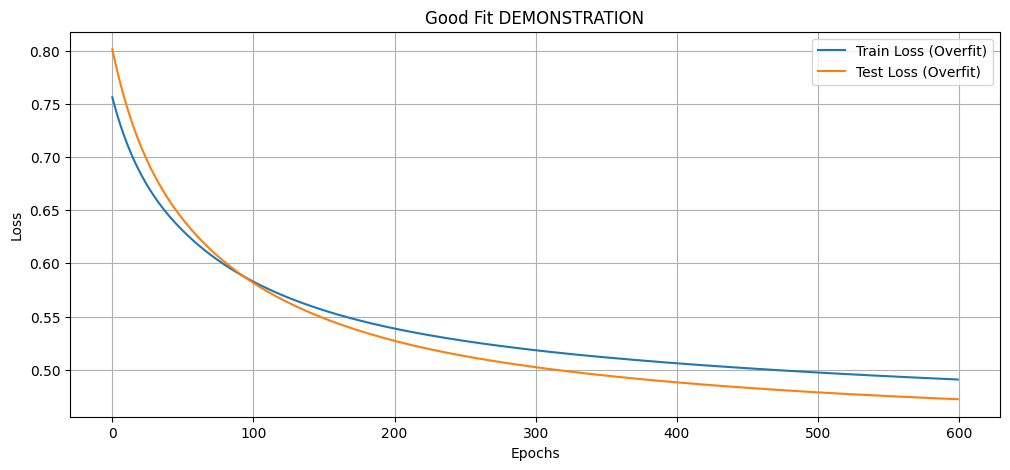

In [40]:
plt.figure(figsize=(12,5))
plt.plot(train_overfit, label="Train Loss (Goodfit)")
plt.plot(test_overfit, label="Test Loss (Goodfit)")
plt.title("Good Fit DEMONSTRATION")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [41]:
# -----------------------------
# 11. STEP 2: TRAIN WITH DROPOUT
# -----------------------------
train2, test2 = train_mlp(dropout=True, early_stop=False)

Epoch 0, Train Loss: 0.9593, Test Loss: 0.8019
Epoch 20, Train Loss: 0.9244, Test Loss: 0.7577
Epoch 40, Train Loss: 0.8501, Test Loss: 0.7206
Epoch 60, Train Loss: 0.8705, Test Loss: 0.6897
Epoch 80, Train Loss: 0.8428, Test Loss: 0.6639
Epoch 100, Train Loss: 0.7673, Test Loss: 0.6420
Epoch 120, Train Loss: 0.7922, Test Loss: 0.6232
Epoch 140, Train Loss: 0.7361, Test Loss: 0.6072
Epoch 160, Train Loss: 0.6973, Test Loss: 0.5934
Epoch 180, Train Loss: 0.7251, Test Loss: 0.5815
Epoch 200, Train Loss: 0.7159, Test Loss: 0.5702
Epoch 220, Train Loss: 0.6801, Test Loss: 0.5601
Epoch 240, Train Loss: 0.7361, Test Loss: 0.5517
Epoch 260, Train Loss: 0.7136, Test Loss: 0.5442
Epoch 280, Train Loss: 0.6626, Test Loss: 0.5376
Epoch 300, Train Loss: 0.6843, Test Loss: 0.5314
Epoch 320, Train Loss: 0.6657, Test Loss: 0.5267
Epoch 340, Train Loss: 0.6520, Test Loss: 0.5221
Epoch 360, Train Loss: 0.6241, Test Loss: 0.5182
Epoch 380, Train Loss: 0.6122, Test Loss: 0.5142
Epoch 400, Train Loss: 0.6

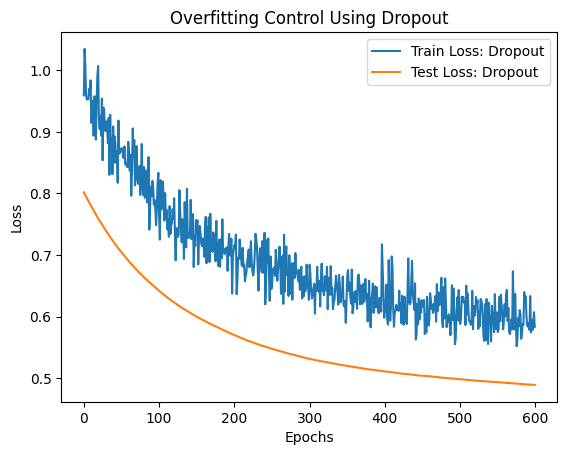

In [42]:
plt.plot(train2, label="Train Loss: Dropout")
plt.plot(test2, label="Test Loss: Dropout")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Overfitting Control Using Dropout")
plt.legend()
plt.show()

In [43]:
# -----------------------------
# 12. STEP 3: TRAIN WITH DROPOUT + EARLY STOPPING
# -----------------------------
train3, test3 = train_mlp(dropout=True, early_stop=True)

Epoch 0, Train Loss: 1.1170, Test Loss: 0.9620
Epoch 20, Train Loss: 0.9833, Test Loss: 0.8380
Epoch 40, Train Loss: 0.9429, Test Loss: 0.7557
Epoch 60, Train Loss: 0.8863, Test Loss: 0.6975
Epoch 80, Train Loss: 0.7881, Test Loss: 0.6545
Epoch 100, Train Loss: 0.8012, Test Loss: 0.6224
Epoch 120, Train Loss: 0.7402, Test Loss: 0.5977
Epoch 140, Train Loss: 0.6924, Test Loss: 0.5772
Epoch 160, Train Loss: 0.6644, Test Loss: 0.5615
Epoch 180, Train Loss: 0.6715, Test Loss: 0.5484
Epoch 200, Train Loss: 0.7184, Test Loss: 0.5381
Epoch 220, Train Loss: 0.6735, Test Loss: 0.5293
Epoch 240, Train Loss: 0.6732, Test Loss: 0.5218
Epoch 260, Train Loss: 0.6599, Test Loss: 0.5151
Epoch 280, Train Loss: 0.6500, Test Loss: 0.5096
Epoch 300, Train Loss: 0.6616, Test Loss: 0.5049
Epoch 320, Train Loss: 0.6317, Test Loss: 0.5003
Epoch 340, Train Loss: 0.6170, Test Loss: 0.4968
Epoch 360, Train Loss: 0.6175, Test Loss: 0.4936
Epoch 380, Train Loss: 0.5937, Test Loss: 0.4907
Epoch 400, Train Loss: 0.6

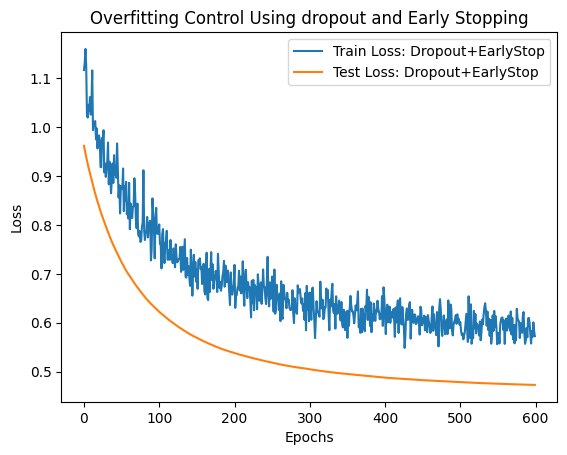

In [44]:
plt.plot(train3, label="Train Loss: Dropout+EarlyStop")
plt.plot(test3, label="Test Loss: Dropout+EarlyStop")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Overfitting Control Using dropout and Early Stopping")
plt.legend()
plt.show()

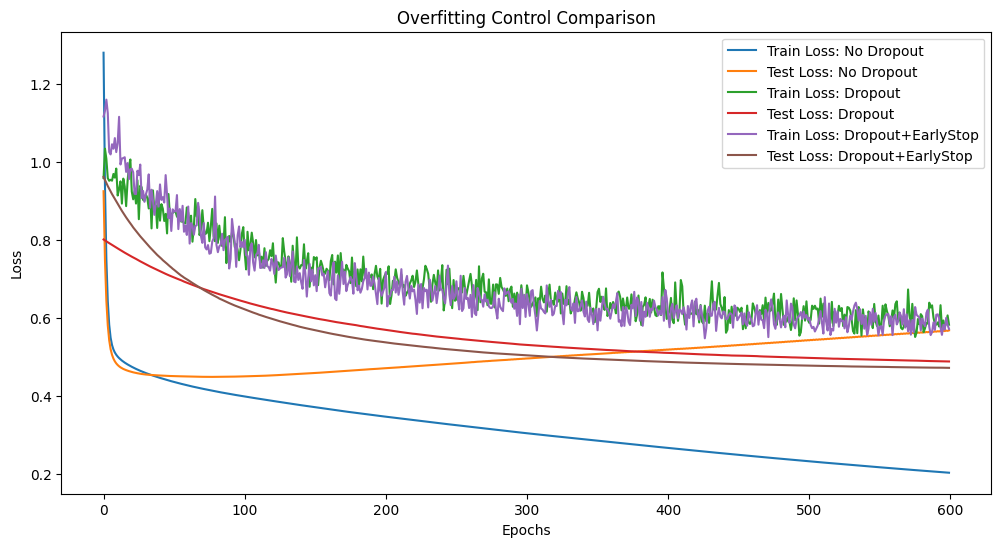

In [45]:
# -----------------------------
# 13. STEP 4: PLOT ALL THREE GRAPHS
# -----------------------------
plt.figure(figsize=(12,6))
plt.plot(train1, label="Train Loss: No Dropout")
plt.plot(test1, label="Test Loss: No Dropout")
plt.plot(train2, label="Train Loss: Dropout")
plt.plot(test2, label="Test Loss: Dropout")
plt.plot(train3, label="Train Loss: Dropout+EarlyStop")
plt.plot(test3, label="Test Loss: Dropout+EarlyStop")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Overfitting Control Comparison")
plt.legend()
plt.show()

1. **No Dropout (Overfitting Case)**
The blue line (train loss) continuously decreases from a high value to a very low value.
The orange line (test loss) initially decreases but later starts increasing.
**Observation:**
A large gap appears between training and test loss.
The model memorizes training data instead of learning general patterns.
**Conclusion:**

This is a clear case of overfitting, where the model performs well on training data but poorly on unseen data.

**2. Dropout Applied (Regularization Effect)**
The green line (train loss) decreases more slowly and becomes noisier.
The red line (test loss) becomes more stable and decreases smoothly.
**Observation:**
The gap between training and test loss is reduced.
The model becomes less sensitive to training data.
**Conclusion:**

Dropout helps reduce overfitting by randomly disabling neurons during training, forcing the model to learn more generalized features.

**3. Dropout + Early Stopping (Best Model)**
The purple line (train loss) decreases but stabilizes earlier.
The brown line (test loss) becomes stable and stops improving after some epochs.
**Observation:**
Training stops at an optimal point.
No unnecessary learning after convergence.
**Conclusion:**
Early stopping prevents over-training and improves generalization performance.

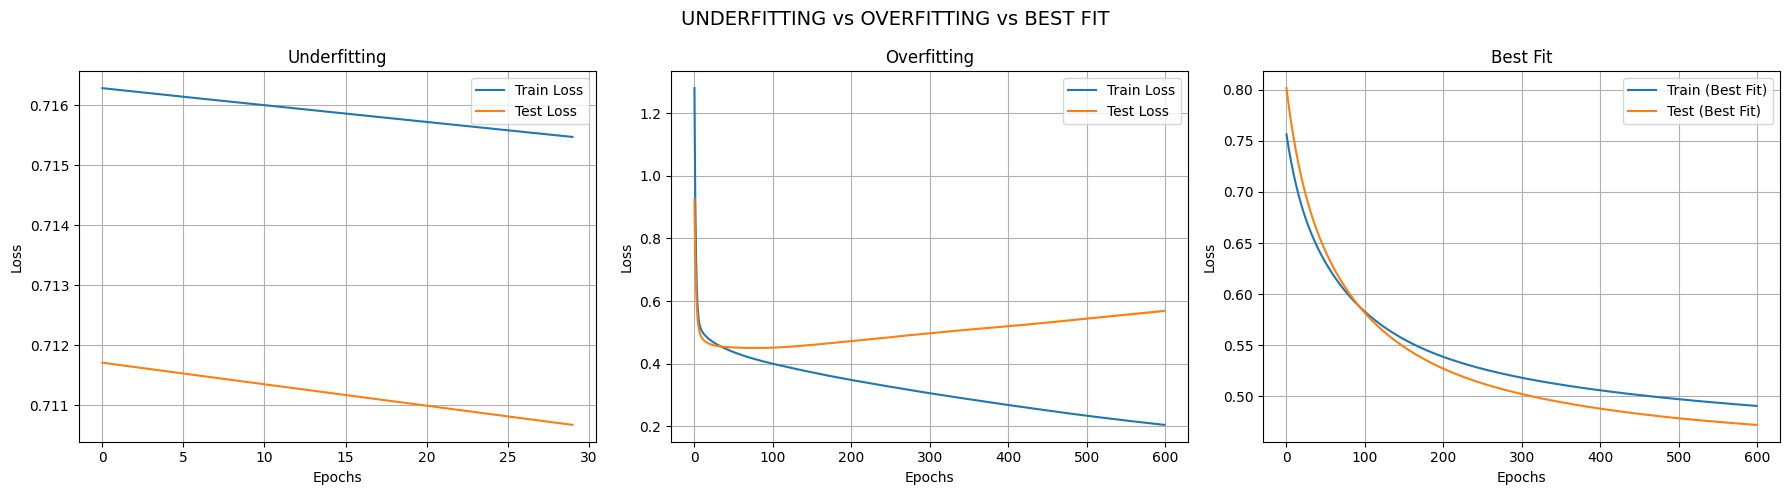

In [50]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ---------------- Underfitting ----------------
axes[0].plot(train_underfit, label="Train Loss")
axes[0].plot(test_underfit, label="Test Loss")
axes[0].set_title("Underfitting")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

# ---------------- Overfitting ----------------
axes[1].plot(train1, label="Train Loss")
axes[1].plot(test1, label="Test Loss")
axes[1].set_title("Overfitting")
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

# ---------------- Best Fit (optional example) ----------------
axes[2].plot(train_overfit, label="Train (Best Fit)")
axes[2].plot(test_overfit, label="Test (Best Fit)")
axes[2].set_title("Best Fit")
axes[2].set_xlabel("Epochs")
axes[2].set_ylabel("Loss")
axes[2].legend()
axes[2].grid(True)

plt.suptitle("UNDERFITTING vs OVERFITTING vs BEST FIT", fontsize=14)
plt.tight_layout()
plt.show()